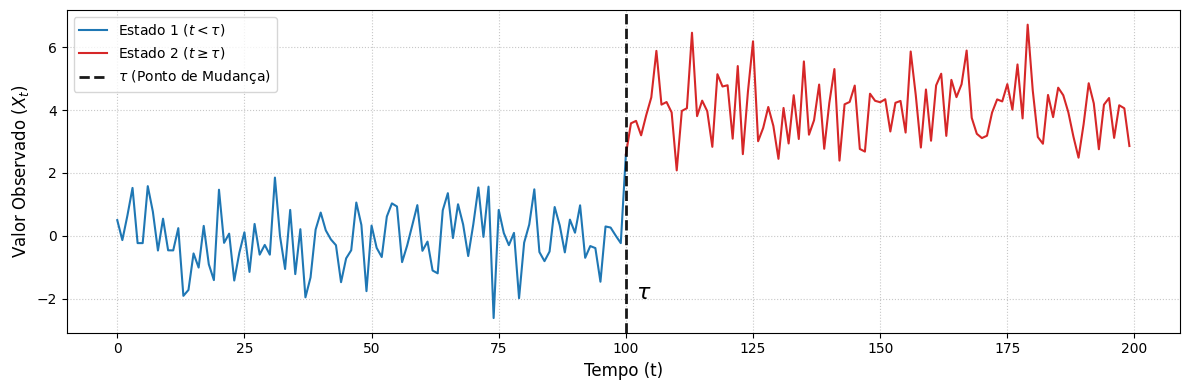

In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

N = 200
tau = 100

X1 = np.random.normal(loc=0, scale=1, size=tau)
X2 = np.random.normal(loc=4, scale=1, size=N - tau)
X = np.concatenate([X1, X2])
t = np.arange(N)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(t[:tau+1], X[:tau+1], color='tab:blue', label=r'Estado 1 ($t < \tau$)')
ax.plot(t[tau:], X[tau:], color='tab:red', label=r'Estado 2 ($t \geq \tau$)')

ax.axvline(x=tau, color='black', linestyle='--', linewidth=2, alpha=0.9, label=r'$\tau$ (Ponto de Mudança)')
ax.text(tau + 2, -2, r'$\tau$', fontsize=16)

# ax.set_title('Ilustração de Série Temporal com Changepoint', fontsize=14)
ax.set_xlabel('Tempo (t)', fontsize=12)
ax.set_ylabel(r'Valor Observado ($X_t$)', fontsize=12)

ax.legend(loc='upper left')
ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

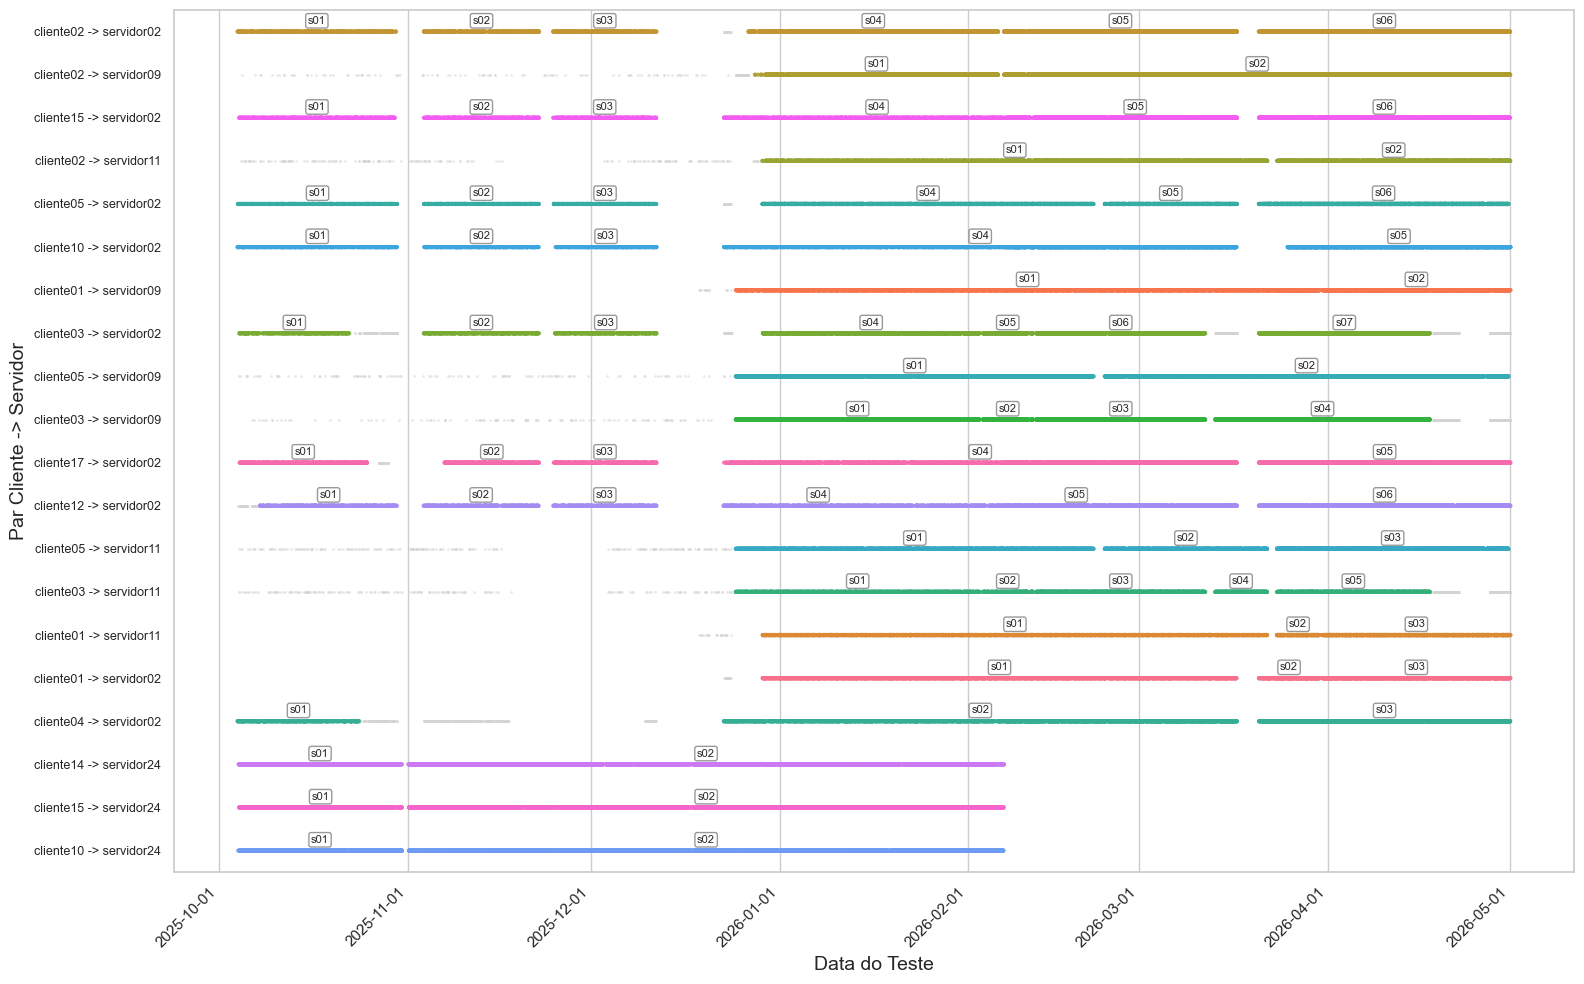

In [11]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import json
import seaborn as sns
import matplotlib.dates as mdates


# Carregamento do dataset
file = 'NDT_transformed.csv'
# file = 'NDT_clean.csv'
file_path = os.path.join("NDT dataset", file)
df = pd.read_csv(file_path)

# # Unificar os servidores dos sites do MLAB
# df['server_name'] = df['server_name'].str.replace(r'MLAB[1-3]-(.*)', r'MLAB-\1', regex=True)

# abreviar para só Computador Curi
df['client_name'] = df['client_name'].str.replace(r'Computador Curi.*', 'Computador Curi', regex=True)

# Anonimizar client_name e server_name
with open(os.path.join("NDT dataset", "mapping_log.json"), "r", encoding="utf-8") as f:
    mapping = json.load(f)
inv_client_map = {v: k for k, v in mapping["client_map"].items()}
inv_server_map = {v: k for k, v in mapping["server_map"].items()}
df["client_name"] = df["client_name"].map(inv_client_map).fillna(df["client_name"])
df["server_name"] = df["server_name"].map(inv_server_map).fillna(df["server_name"])

# Criar coluna de par cliente-servidor
df['client_server_pair'] = df['client_name'] + " -> " + df['server_name']

# Conversão de timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['data'] = df['timestamp'].dt.date

# Ordenar por tempo e par
df = df.sort_values(by=['client_server_pair', 'timestamp']).reset_index(drop=True)

# Criar coluna com a diferença de tempo
df['delta_tempo_horas'] = df.groupby('client_server_pair')['timestamp'].diff().dt.total_seconds() / 3600

# 1. Filtro de tipo e Dropna (em todas as colunas existentes até aqui)
df_clean = df[df['tipo'] == 'raspberry'].copy()
df_clean = df_clean.dropna()

# 2. Filtro de métricas negativas
metricas = ['rtt_download', 'throughput_download', 'rtt_upload', 'throughput_upload', 'packet_loss']
for col in metricas:
    if col in df_clean.columns:
        df_clean = df_clean[df_clean[col] >= 0]

# 3. Criar par e converter timestamp
df_clean['client_server_pair'] = df_clean['client_name'] + " -> " + df_clean['server_name']
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'], utc=True)

# 4. Remover duplicatas ANTES de qualquer lógica de tempo (Crucial)
duplicatas = df_clean.duplicated(subset=['client_server_pair', 'timestamp'], keep=False)
df_clean = df_clean[~duplicatas].copy()

# 5. Ordenar (A função faz isso antes de filtrar data e calcular delta)
df_clean = df_clean.sort_values(by=['client_server_pair', 'timestamp']).reset_index(drop=True)

# 6. Filtro de data (Exatamente como na função)
data_inicio = pd.to_datetime('2025-10-04', utc=True)
df_clean = df_clean[df_clean['timestamp'] >= data_inicio].copy()

# 7. Cálculo do Delta (Feito após a limpeza e filtro de data na função)
df_clean['delta_tempo_horas'] = df_clean.groupby('client_server_pair')['timestamp'].diff().dt.total_seconds() / 3600

# 8. Lógica de blocos
limite_horas = 12.0
seg_min = 300

condicao_quebra = df_clean['delta_tempo_horas'] > limite_horas
df_clean['id_bloco'] = condicao_quebra.groupby(df_clean['client_server_pair']).cumsum()
df_clean['tamanho_bloco'] = df_clean.groupby(['client_server_pair', 'id_bloco'])['id_bloco'].transform('count')

# 9. Filtro de tamanho e Rank denso
df_clean = df_clean[df_clean['tamanho_bloco'] >= seg_min].copy()
df_clean['id_bloco'] = df_clean.groupby('client_server_pair')['id_bloco'].rank(method='dense').astype(int)

# 1. Cria a lista com os PARES ordenados pelo volume de uso
ordem_pares = df_clean['client_server_pair'].value_counts().index[:20]
df_clean = df_clean[df_clean['client_server_pair'].isin(ordem_pares)].copy()

# Modificações para a tese
# ordem_pares = ordem_pares[:20]
data_inicio = pd.to_datetime('2025-10-04', utc=True)
df_2 = df[df['timestamp'] >= data_inicio].copy()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 10)) 

# 2. Usando STRIPPLOT por Par
sns.stripplot(
    data=df_2,
    x='timestamp', 
    y='client_server_pair',
    color='lightgray',
    size=2,
    alpha=0.5,
    order=ordem_pares,
    jitter=False,
    zorder=1
)
sns.stripplot(
    data=df_clean,
    x='timestamp', 
    y='client_server_pair',
    hue='client_server_pair',
    palette="husl",
    size=3,
    alpha=0.8,
    legend=False,
    order=ordem_pares,
    jitter=False,
    zorder=2
)

# --- ADIÇÃO DAS CAIXAS DE TEXTO PARA OS SEGMENTOS ---

# Mapeia cada par para sua posição numérica no eixo Y (0, 1, 2...) baseada na ordem do plot
y_mapping = {par: i for i, par in enumerate(ordem_pares)}

# Agrupa por par e por bloco
for (par, bloco), group in df_clean.groupby(['client_server_pair', 'id_bloco']):
    
    # Encontra o meio do segmento no eixo X (data/hora)
    x_min = group['timestamp'].min()
    x_max = group['timestamp'].max()
    x_center = x_min + (x_max - x_min) / 2
    
    # Pega a posição Y correspondente ao par
    y_pos = y_mapping[par]
    
    # Adiciona a caixa de texto
    plt.text(
        x=x_center, 
        y=y_pos - 0.25, # O -0.25 desloca a caixa um pouco para cima para não cobrir a linha
        s=f"s{int(bloco):02d}", 
        fontsize=8,
        ha='center', # Centraliza o texto no eixo X
        va='center', # Centraliza o texto no eixo Y
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8), # Cria a caixa visual
        zorder=3
    )
# -----------------------------------------------------

# plt.title('Linha do Tempo de Atividade: Medições por Par Cliente-Servidor', fontsize=18, pad=20)
plt.xlabel('Data do Teste', fontsize=14)
plt.ylabel('Par Cliente -> Servidor', fontsize=14)

# Formatação do eixo X (Tempo)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=9) # Fonte menor para os nomes dos pares

plt.tight_layout()
plt.show()

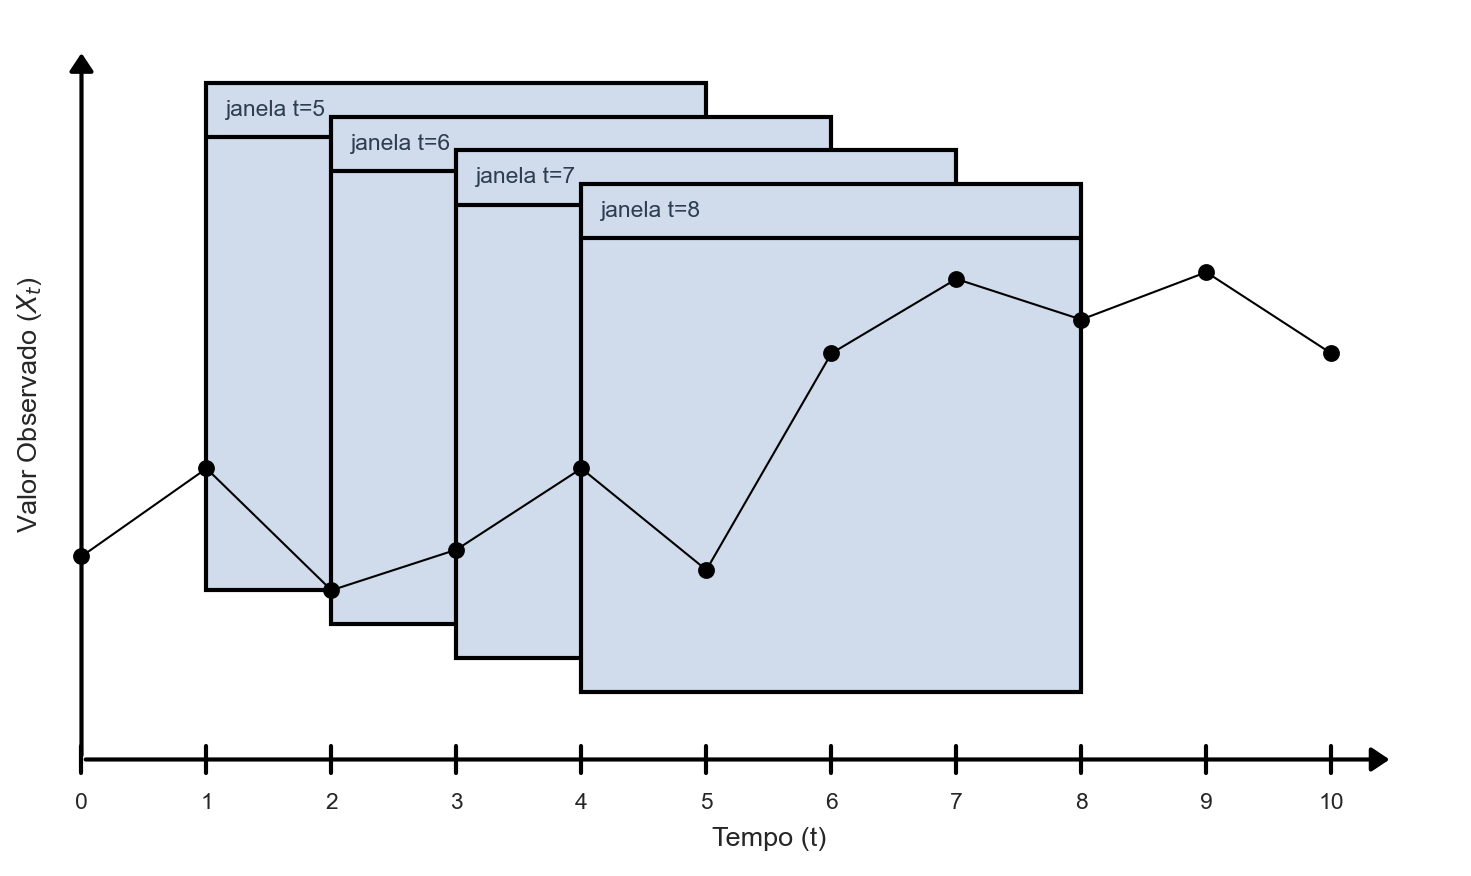

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

ax.set_xlim(-0.5, 11)
ax.set_ylim(-1.5, 11)
ax.axis('off')

ax.annotate('', xy=(10.5, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>,head_width=0.4,head_length=0.6", lw=2, color='black'))
ax.annotate('', xy=(0, 10.5), xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>,head_width=0.4,head_length=0.6", lw=2, color='black'))

# ax.text(5, -1.0, 'amostra (t)', ha='center', va='top', fontsize=12)
# ax.text(0, 10.8, 'x(t)', ha='center', va='bottom', fontsize=12)

font_axis = {'family': 'sans-serif', 'weight': 'normal', 'size': 13}
ax.text(5.5, -1.0, 'Tempo (t)', ha='center', va='top', fontdict=font_axis)
ax.text(-0.3, 5.25, 'Valor Observado ($X_t$)', ha='right', va='center', rotation='vertical', fontdict=font_axis)

ax.set_xlabel('Tempo (t)', fontsize=12)
ax.set_ylabel(r'Valor Observado ($X_t$)', fontsize=12)


for i in range(11):
    ax.plot([i, i], [0.2, -0.2], color='black', lw=2)
    ax.text(i, -0.5, str(i), ha='center', va='top', fontsize=11)

windows = [
    {'t': 5, 'x': 1, 'y': 2.5, 'w': 4, 'h': 7.5},
    {'t': 6, 'x': 2, 'y': 2.0, 'w': 4, 'h': 7.5},
    {'t': 7, 'x': 3, 'y': 1.5, 'w': 4, 'h': 7.5},
    {'t': 8, 'x': 4, 'y': 1.0, 'w': 4, 'h': 7.5},
]

fill_color = '#d0dceb'

for w in windows:
    rect = patches.Rectangle((w['x'], w['y']), w['w'], w['h'], 
                             linewidth=2, edgecolor='black', facecolor=fill_color, zorder=2)
    ax.add_patch(rect)
    
    header_y = w['y'] + w['h'] - 0.8
    ax.plot([w['x'], w['x'] + w['w']], [header_y, header_y], color='black', lw=2, zorder=2)
    
    ax.text(w['x'] + 0.15, w['y'] + w['h'] - 0.4, f'janela t={w["t"]}', 
            ha='left', va='center', fontsize=11, color='#2c3e50', zorder=3)
    
    # if w['t'] == 8:
    #     bottom_y = w['y'] + 1.2
    #     ax.plot([w['x'], w['x'] + w['w']], [bottom_y, bottom_y], color='black', lw=2, zorder=2)

x_data = np.arange(11)
y_data = [3.0, 4.3, 2.5, 3.1, 4.3, 2.8, 6.0, 7.1, 6.5, 7.2, 6.0]

ax.plot(x_data, y_data, color='black', lw=1, zorder=4)
ax.scatter(x_data, y_data, color='black', s=50, zorder=5)

plt.tight_layout()
plt.show()

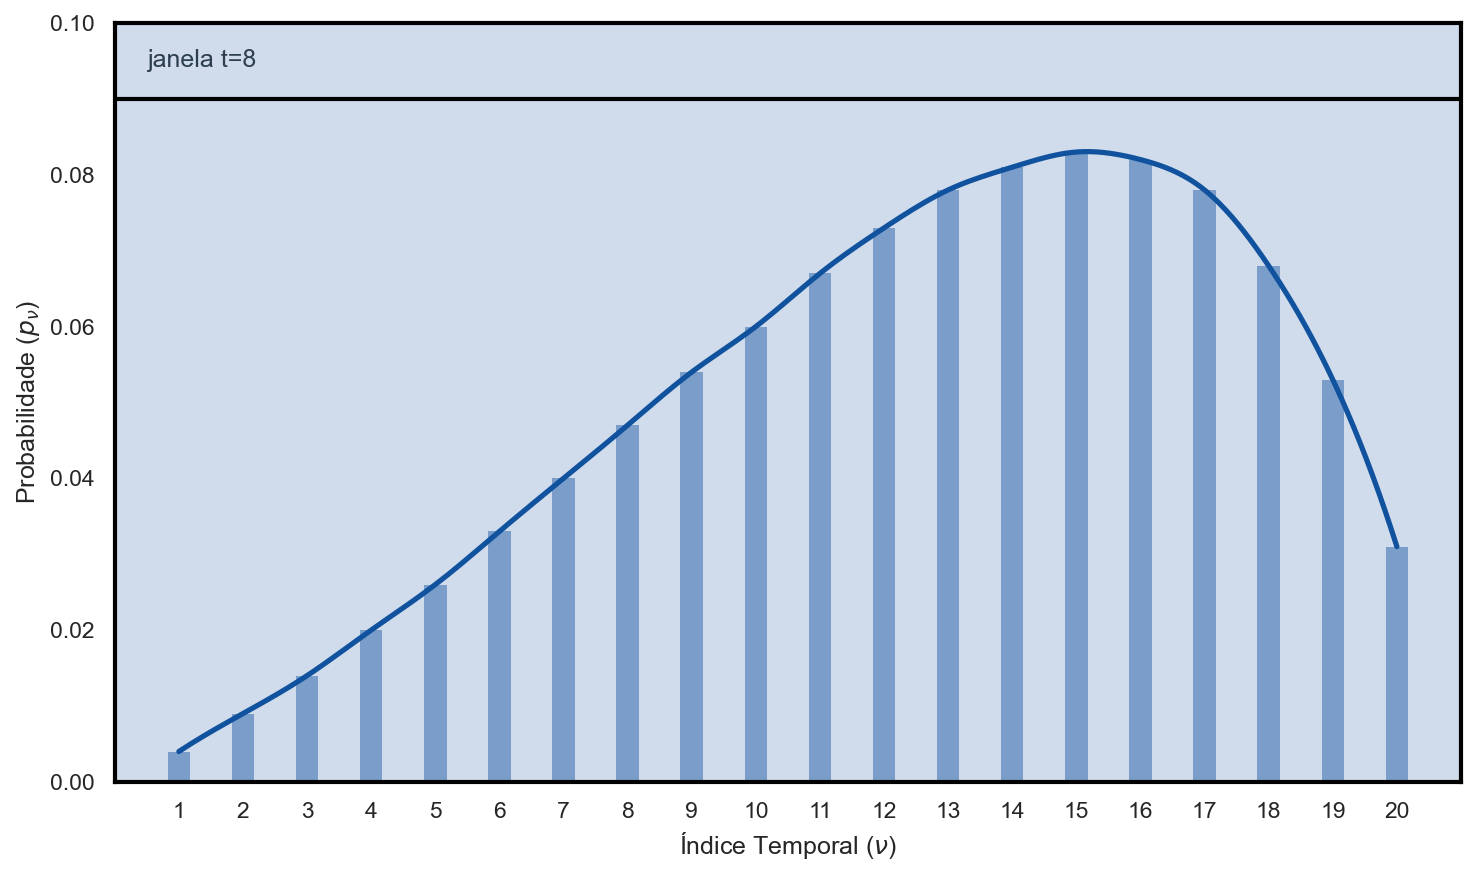

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

# Padrão de cor de fundo ("janela" da figura anterior)
bg_color = '#d0dceb'
header_text_color = '#2c3e50'
ax.set_facecolor(bg_color)

# Reconstrução dos dados com base na imagem
x_bar = np.arange(1, 21)
y_bar = np.array([
    0.004, 0.009, 0.014, 0.020, 0.026, 0.033, 0.040, 0.047, 
    0.054, 0.060, 0.067, 0.073, 0.078, 0.081, 0.083, 0.082, 
    0.078, 0.068, 0.053, 0.031
])

# Interpolação para a curva suave
spline = make_interp_spline(x_bar, y_bar, k=3)
x_smooth = np.linspace(1, 20, 200)
y_smooth = spline(x_smooth)

# Cores para os gráficos (harmonizando com o fundo)
bar_color = '#7a9ec9' 
line_color = '#10529e'

# Plotagem das barras e linha
ax.bar(x_bar, y_bar, width=0.35, color=bar_color, edgecolor='none', zorder=2)
ax.plot(x_smooth, y_smooth, color=line_color, lw=2.5, zorder=3)

# Configuração dos limites e marcações dos eixos
ax.set_xlim(0, 21)
ax.set_ylim(0, 0.10)
ax.set_xticks(np.arange(1, 21))

# Labels com fonte em português e formatação adequada
ax.set_xlabel('Índice Temporal ($\\nu$)', fontsize=12)
ax.set_ylabel('Probabilidade ($p_\\nu$)', fontsize=12)
# ax.set_title('Distribuição de Probabilidade na Janela', fontsize=14, pad=20)

# Elementos visuais para identificar que esta é a "janela t=8" da figura anterior
# 1. Borda grossa preta imitando o contorno da janela
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

# 2. Linha divisória do cabeçalho da janela
header_y = 0.09
ax.plot([0, 21], [header_y, header_y], color='black', lw=2, zorder=4)

# 3. Texto do cabeçalho
ax.text(0.5, 0.095, 'janela t=8', ha='left', va='center', 
        fontsize=12, color=header_text_color, zorder=5)

ax.grid(False)
plt.tight_layout()
plt.show()

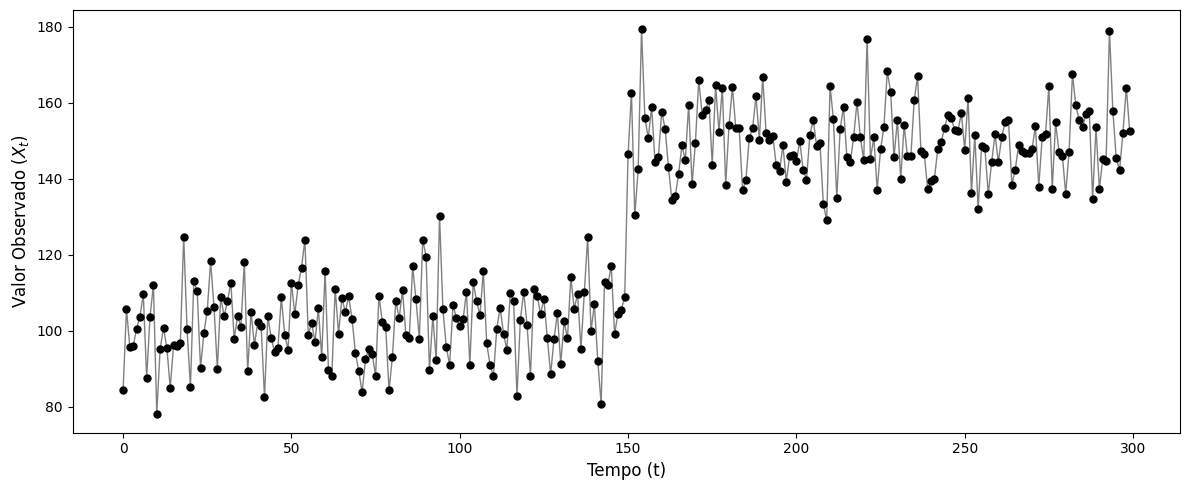

In [8]:
import os
from matplotlib import pyplot as plt
import pandas as pd

def plot_changepoint(cenario, methods, file, threshold=0.95, tail_plot=False, slice_window=["", ""], alias="", metric=None):
    if isinstance(methods, str):
        methods = [methods] if methods else []
        
    base_types = []
    vwcd_method = None
    for m in methods:
        if m.startswith('vwcd'):
            base_types.append('vwcd')
            vwcd_method = m
        elif m.startswith('cusum'):
            base_types.append('cusum')
        elif m.startswith('pelt'):
            base_types.append('pelt')
        else:
            raise ValueError(f"Method '{m}' must start with 'vwcd', 'cusum', or 'pelt'.")
            
    for b_type in set(base_types):
        if base_types.count(b_type) > 1:
            raise ValueError(f"Cannot pass more than one method of type '{b_type}'.")

    if tail_plot and not vwcd_method:
        raise ValueError("Tail plot is only available if a 'vwcd' method is provided.")

    start = pd.to_datetime(slice_window[0]) if (len(slice_window) > 0 and slice_window[0]) else None
    end = pd.to_datetime(slice_window[1]) if (len(slice_window) > 1 and slice_window[1]) else None

    def load_and_slice_df(filepath):
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"File not found: {filepath}")
        df = pd.read_csv(filepath)
        df['timestamp'] = pd.to_datetime(df['timestamp'], format='%Y-%m-%d %H:%M:%S')
        if start:
            df = df[df['timestamp'] >= start]
        if end:
            df = df[df['timestamp'] <= end]
        # return df
        return df.reset_index(drop=True)

    metric_val = metric if metric else cenario
    serie_file = os.path.join('series', metric_val, file)
    df_serie = load_and_slice_df(serie_file)

    if df_serie.empty:
        return
    
    value_column = [col for col in df_serie.columns if col != 'timestamp'][0]

    df_methods = {}
    for m in methods:
        if m.startswith('vwcd'):
            path = os.path.join('results', cenario, m, 'tail_probability_theta_ge_Tstar', file)
        elif m.startswith('cusum'):
            path = os.path.join('results', cenario, m, file)
        elif m.startswith('pelt'):
            path = os.path.join('results', cenario, m, file)
        df_methods[m] = load_and_slice_df(path)  # type: ignore

    ax2 = None
    if tail_plot:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    else:
        fig, ax1 = plt.subplots(figsize=(12, 5))
    
    # ax1.plot(df_serie['timestamp'], df_serie[value_column], label='Data',
    ax1.plot(df_serie.index, df_serie[value_column], label='Data', 
             linewidth=1, color='gray', marker='o', 
             markerfacecolor='black', markeredgecolor='black', markersize=5)

    for m in methods:
        df_m = df_methods[m]
        if m.startswith('vwcd'):
            # cps = df_m[df_m['P_theta_ge_Tstar'] > threshold]['timestamp']
            cps = df_m[df_m['P_theta_ge_Tstar'] > threshold].index
            color, ls, lw, zo, lbl, alpha = 'red', '-', 4, 2, 'CP VWCD', 0.7
        elif m.startswith('cusum'):
            # cps = df_m[df_m['CP'] == 1]['timestamp']
            cps = df_m[df_m['CP'] == 1].index
            color, ls, lw, zo, lbl, alpha = 'green', '--', 2, 3, 'CP CUSUM', 1.0
        elif m.startswith('pelt'):
            # cps = df_m[df_m['CP'] == 1]['timestamp']
            cps = df_m[df_m['CP'] == 1].index
            color, ls, lw, zo, lbl, alpha = 'blue', ':', 2.5, 4, 'CP PELT', 1.0

        for i, cp in enumerate(cps): # type: ignore
            ax1.axvline(x=cp, color=color, linestyle=ls, linewidth=lw,  # type: ignore
                        alpha=alpha, zorder=zo, label=lbl if i == 0 else "") # type: ignore

    # file_alias = f"{file} ({alias})" if alias != "" else file
    # if len(methods) == 0:
    #     ax1.set_title(f'Time Series - {file_alias}')
    # elif len(methods) > 1:
    #     ax1.set_title(f'Change Point Detection Comparison - {file_alias}')
    # else:
    #     ax1.set_title(f'{methods[0].upper()} - {file_alias}')
        
    ax1.set_ylabel(r'Valor Observado ($X_t$)', fontsize=12)
    ax1.set_xlabel('Tempo (t)', fontsize=12)
    # ax1.legend(loc='lower right')

    if tail_plot and vwcd_method and ax2 is not None:
        df_tail = df_methods[vwcd_method]
        # ax2.plot(df_tail['timestamp'], df_tail['P_theta_ge_Tstar'], color='gray', label='Tail Probability')
        ax2.plot(df_tail.index, df_tail['P_theta_ge_Tstar'], color='gray', label='Tail Probability')
        ax2.axhline(y=threshold, color='red', linestyle='-', label=f'Threshold ({threshold})')
        ax2.set_title(r"Tail Probability Over Time: $P(\theta \geq T^*)$")
        ax2.set_ylabel(r"$P(\theta \geq T^*)$")
        ax2.set_xlabel('Tempo (t)', fontsize=12)
        ax2.legend(loc='center right')

    fig.tight_layout()

    plt.show()
    
    plt.close("all")

cenario = "teste_m150"
method = "vwcd_w24_fp2"
file = "teste01.csv"

plot_changepoint(cenario, method, file, threshold=0.99)


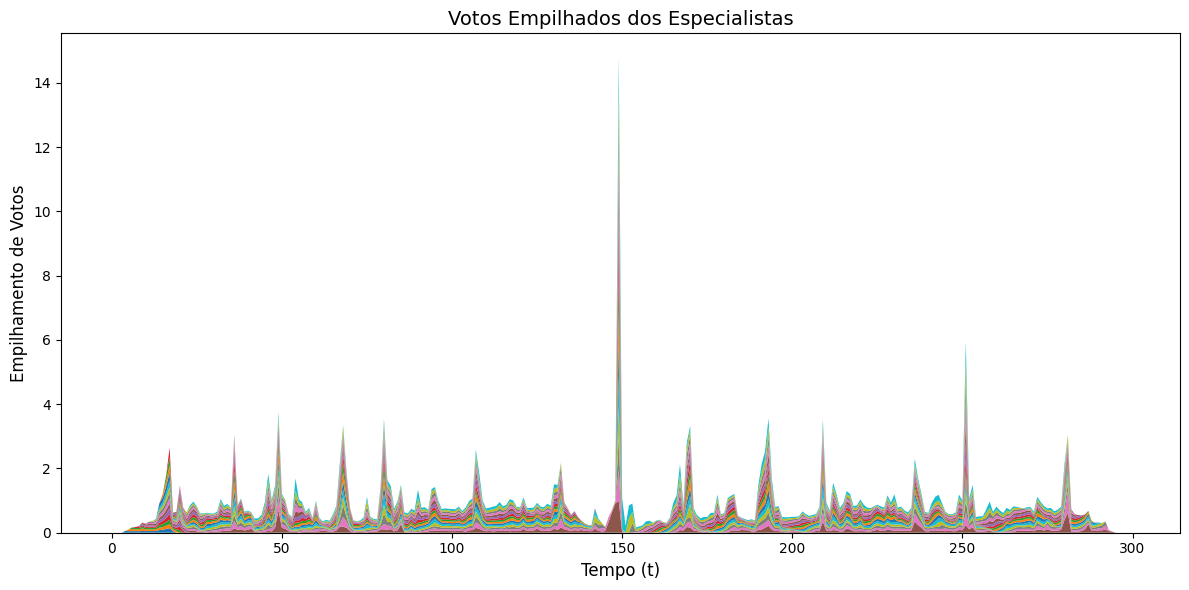

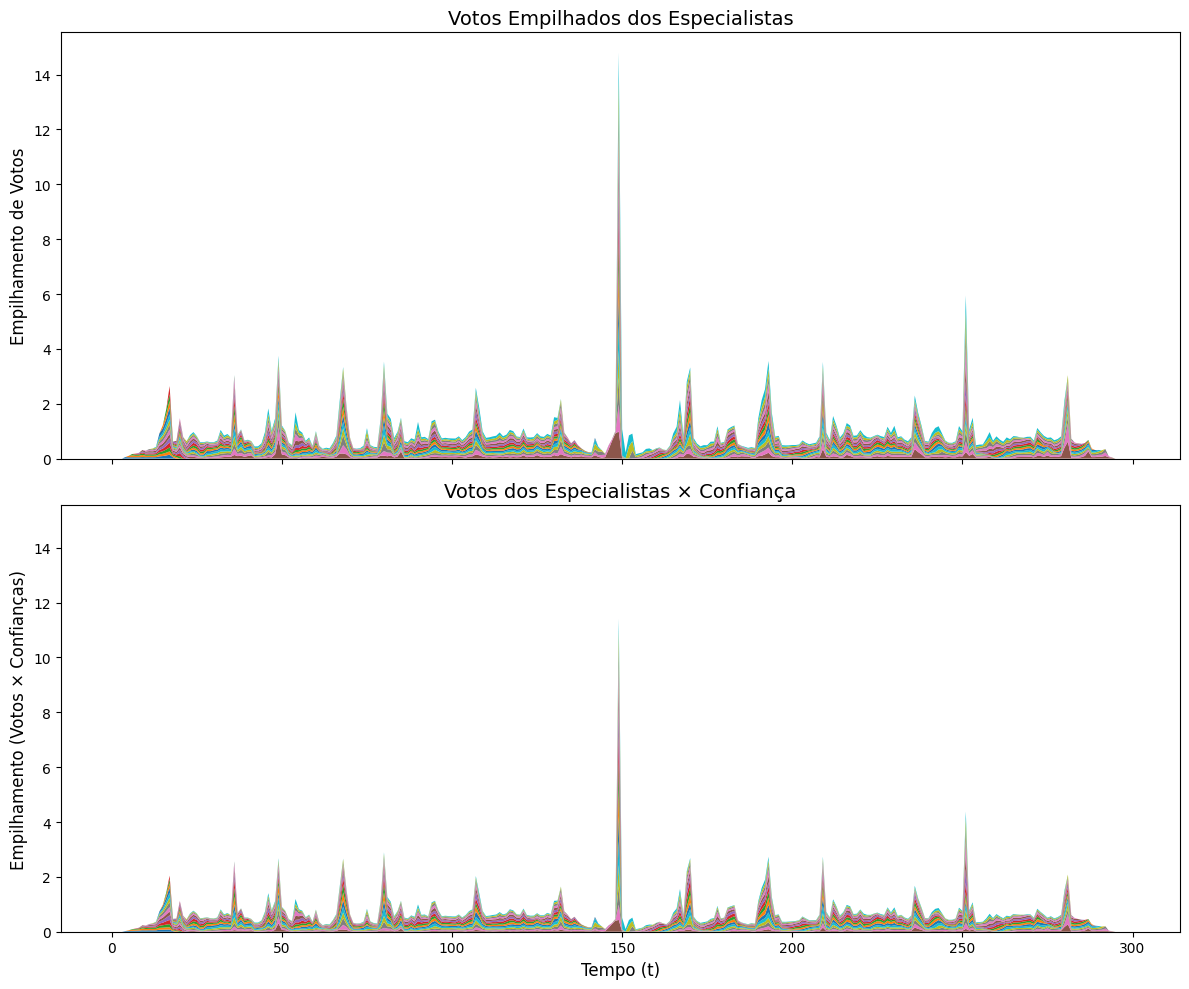

In [35]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List

def plot_stacked_votes(
    times: np.ndarray,
    votes_mat: np.ndarray,
    conf_mat: np.ndarray,
    vote_cols: List[str],
    mode: str = 'both', 
    x_axis_type: str = 'timestamp',
    file=None
) -> None:
    
    if mode not in ['votes', 'conf', 'both']:
        raise ValueError("O parâmetro 'mode' deve ser 'votes', 'conf' ou 'both'.")
        
    if x_axis_type not in ['timestamp', 'index']:
        raise ValueError("O parâmetro 'x_axis_type' deve ser 'timestamp' ou 'index'.")

    if mode == 'both':
        fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True, sharey=True)
        ax_votes, ax_conf = axes
    else:
        fig, ax = plt.subplots(figsize=(12, 6))
        ax_votes = ax if mode == 'votes' else None
        ax_conf = ax if mode == 'conf' else None

    labels_votes = vote_cols
    labels_conf = [f"{vc}×conf" for vc in vote_cols]

    ys_votes = [votes_mat[:, j] for j in range(votes_mat.shape[1])]
    
    votes_times_conf = votes_mat * conf_mat
    ys_conf = [votes_times_conf[:, j] for j in range(votes_times_conf.shape[1])]

    x_data = times if x_axis_type == 'timestamp' else np.arange(len(times))

    def _do_stackplot(ax, ys, labels, title, ylabel):
        ax.stackplot(x_data, ys, labels=labels)
        ax.set_title(title, fontsize=14)
        ax.set_ylabel(ylabel, fontsize=12)

    if ax_votes is not None:
        _do_stackplot(ax_votes, ys_votes, labels_votes, 
                      "Votos Empilhados dos Especialistas", "Empilhamento de Votos")
        if mode == 'votes':
            ax_votes.set_xlabel("Tempo (t)", fontsize=12)

    if ax_conf is not None:
        _do_stackplot(ax_conf, ys_conf, labels_conf, 
                      "Votos dos Especialistas × Confiança", "Empilhamento (Votos × Confianças)")
        ax_conf.set_xlabel("Tempo (t)", fontsize=12)

    fig.tight_layout()
    
    if file:
        if os.path.exists(file):
            os.remove(file)
        fig.savefig(file)
    else:
        plt.show()
        
    plt.close(fig)

votes_file = "results/teste_m150/vwcd_w24_fp2/votes/teste01.csv"
conf_file = "results/teste_m150/vwcd_w24_fp2/confs/teste01.csv"

df_votes = pd.read_csv(votes_file)
df_conf = pd.read_csv(conf_file)

ts_votes = df_votes.columns[0]
vote_cols = list(df_votes.columns[2:]) 
n_exp = len(vote_cols)

ts_conf = df_conf.columns[0]
conf_cols = list(df_conf.columns[1:1 + n_exp])

df_votes[ts_votes] = pd.to_datetime(df_votes[ts_votes])
df_conf[ts_conf] = pd.to_datetime(df_conf[ts_conf])

merged = pd.merge(
    df_votes, df_conf,
    left_on=ts_votes, right_on=ts_conf,
    how="inner",
    suffixes=("", "_conf")
)

times = merged[ts_votes].to_numpy()
votes_mat = merged[vote_cols].to_numpy(dtype=float)
conf_mat = merged[conf_cols].to_numpy(dtype=float)

plot_stacked_votes(times, votes_mat, conf_mat, vote_cols, mode='votes', x_axis_type='index')
plot_stacked_votes(times, votes_mat, conf_mat, vote_cols, mode='both', x_axis_type='index')

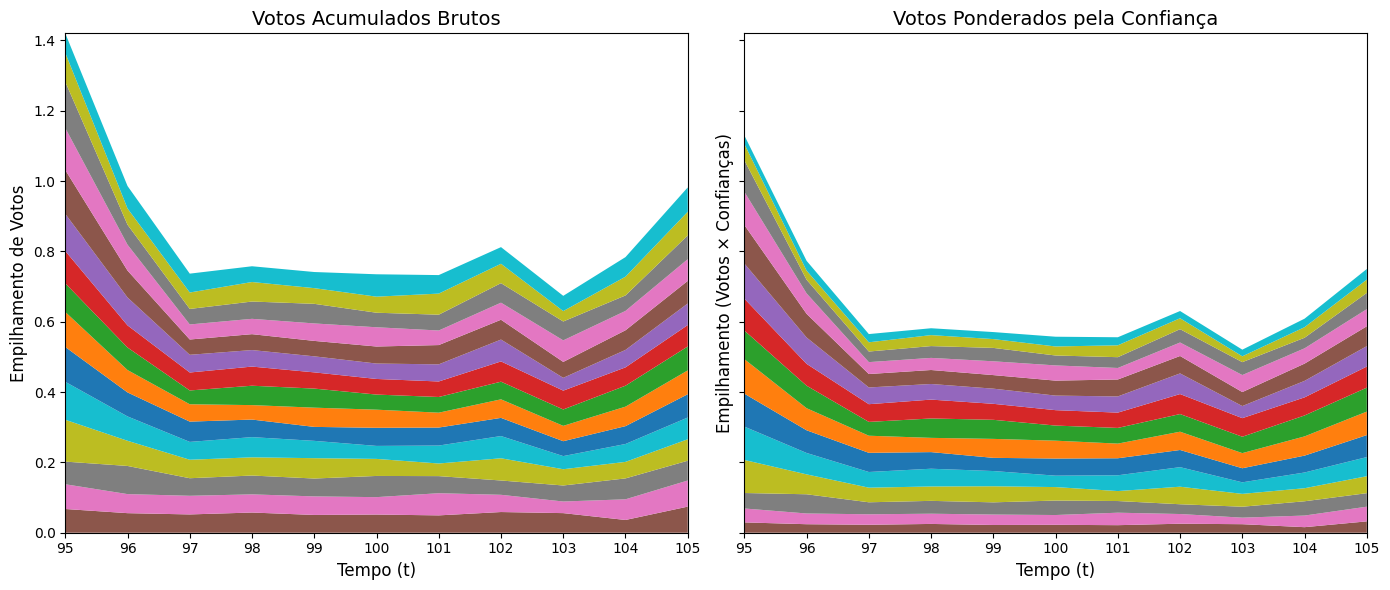

In [33]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Union
from matplotlib.ticker import MaxNLocator

def plot_zoomed_stacked_votes_comparison(
    times: np.ndarray,
    votes_mat: np.ndarray,
    conf_mat: np.ndarray,
    vote_cols: List[str],
    zoom_center: Union[str, pd.Timestamp],
    zoom_radius: int = 50,
    x_axis_type: str = 'timestamp',
    file=None
) -> None:
    
    if x_axis_type not in ['timestamp', 'index']:
        raise ValueError("O parâmetro 'x_axis_type' deve ser 'timestamp' ou 'index'.")

    # Localizar o índice correspondente ao timestamp central
    times_pd = pd.to_datetime(times)
    center_ts = pd.to_datetime(zoom_center)
    
    diffs = np.abs(times_pd - center_ts)
    center_idx = diffs.argmin()
    
    # Definir os limites da janela de zoom
    start_idx = max(0, center_idx - zoom_radius)
    end_idx = min(len(times), center_idx + zoom_radius + 1)
    
    # Fatiar os dados
    sliced_times = times[start_idx:end_idx]
    sliced_votes = votes_mat[start_idx:end_idx, :]
    sliced_conf = conf_mat[start_idx:end_idx, :]
    
    x_data = sliced_times if x_axis_type == 'timestamp' else np.arange(start_idx, end_idx)
    
    ys_votes = [sliced_votes[:, j] for j in range(sliced_votes.shape[1])]
    
    sliced_votes_times_conf = sliced_votes * sliced_conf
    ys_conf = [sliced_votes_times_conf[:, j] for j in range(sliced_votes_times_conf.shape[1])]

    # Criar a figura com 1 linha e 2 colunas
    fig, (ax_votes, ax_conf) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    # Plot (a)
    ax_votes.stackplot(x_data, ys_votes)
    ax_votes.set_title("Votos Acumulados Brutos", fontsize=14)
    ax_votes.set_ylabel("Empilhamento de Votos", fontsize=12)
    ax_votes.set_xlabel("Tempo (t)", fontsize=12)
    ax_votes.margins(x=0, y=0)

    # Plot (b)
    ax_conf.stackplot(x_data, ys_conf)
    ax_conf.set_ylabel("Empilhamento (Votos × Confianças)", fontsize=12)
    ax_conf.set_title("Votos Ponderados pela Confiança", fontsize=14)
    ax_conf.set_xlabel("Tempo (t)", fontsize=12)
    ax_conf.margins(x=0, y=0)

    if x_axis_type == 'index':
        ax_votes.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax_conf.xaxis.set_major_locator(MaxNLocator(integer=True))

    fig.tight_layout()
    
    if file:
        if os.path.exists(file):
            os.remove(file)
        fig.savefig(file)
    else:
        plt.show()
        
    plt.close(fig)


# =====================================================================
# Exemplo de extração de dados e chamada da função
# =====================================================================

votes_file = "results/teste_m150/vwcd_w24_fp2/votes/teste01.csv"
conf_file = "results/teste_m150/vwcd_w24_fp2/confs/teste01.csv"

if os.path.exists(votes_file) and os.path.exists(conf_file):
    df_votes = pd.read_csv(votes_file)
    df_conf = pd.read_csv(conf_file)

    ts_votes = df_votes.columns[0]
    vote_cols = list(df_votes.columns[2:]) 
    n_exp = len(vote_cols)

    ts_conf = df_conf.columns[0]
    conf_cols = list(df_conf.columns[1:1 + n_exp])

    df_votes[ts_votes] = pd.to_datetime(df_votes[ts_votes])
    df_conf[ts_conf] = pd.to_datetime(df_conf[ts_conf])

    merged = pd.merge(
        df_votes, df_conf,
        left_on=ts_votes, right_on=ts_conf,
        how="inner",
        suffixes=("", "_conf")
    )

    times = merged[ts_votes].to_numpy()
    votes_mat = merged[vote_cols].to_numpy(dtype=float)
    conf_mat = merged[conf_cols].to_numpy(dtype=float)

    # Escolhendo um timestamp central qualquer para o zoom (ex: metade da série)
    timestamp_centro = times[100]

    plot_zoomed_stacked_votes_comparison(
        times=times, 
        votes_mat=votes_mat, 
        conf_mat=conf_mat, 
        vote_cols=vote_cols, 
        zoom_center=timestamp_centro, 
        zoom_radius=5,  # Janela de zoom: 30 amostras para trás e 30 para frente
        x_axis_type='index'
    )

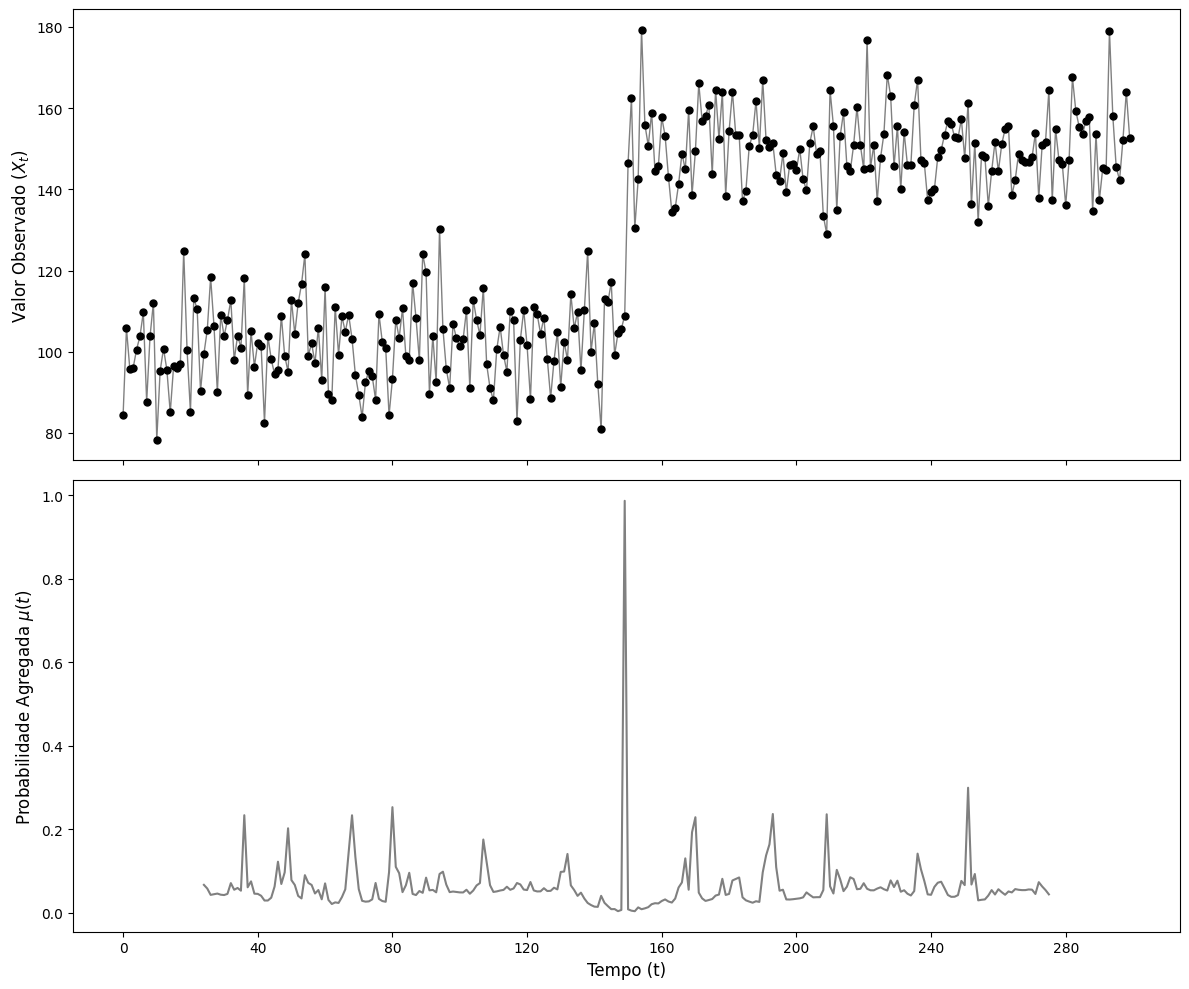

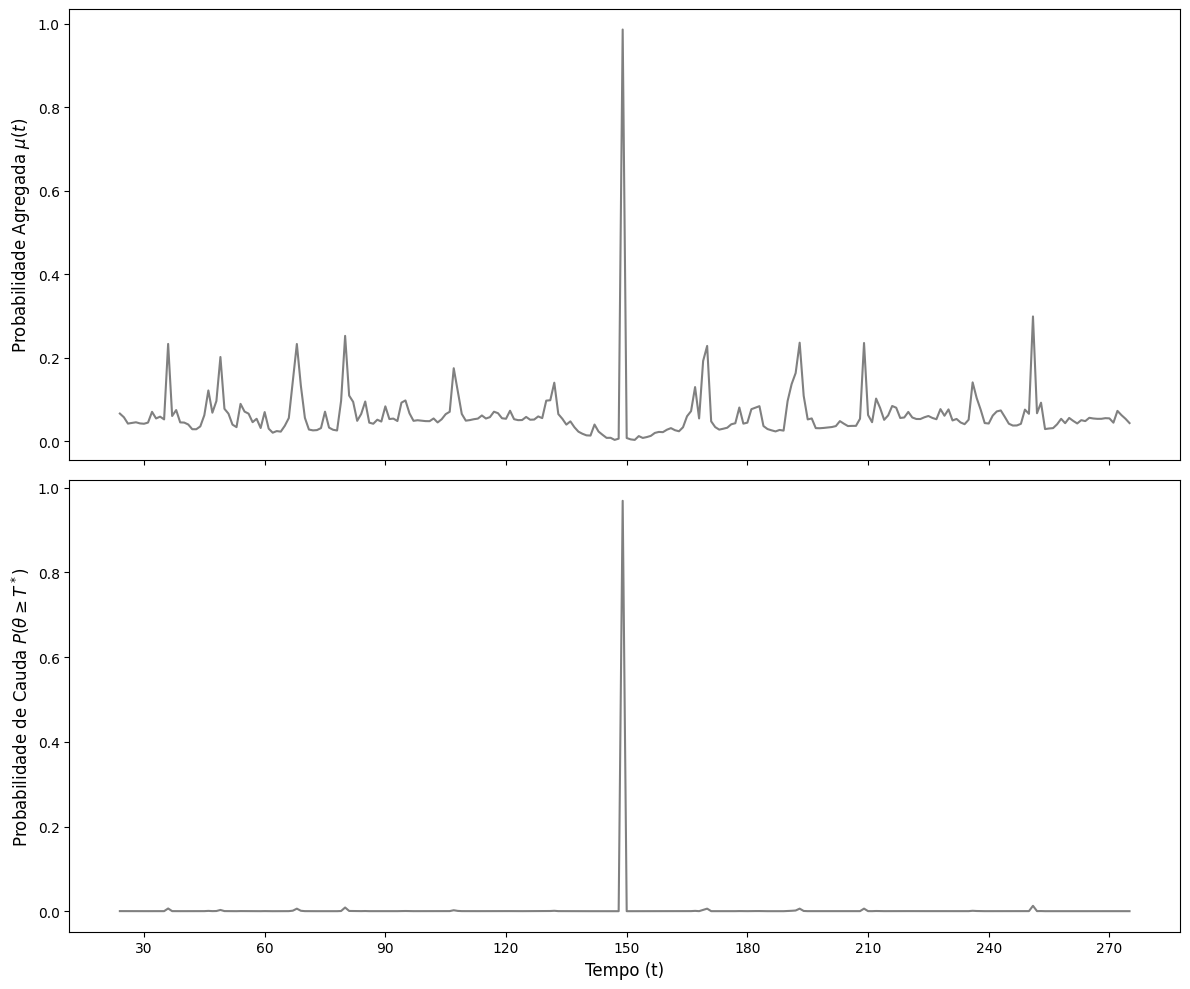

In [52]:
import os
from matplotlib import pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator

def plot_changepoint(cenario, methods, file, threshold=0.95, tail_plot=False, agg_plot=False, slice_window=["", ""], alias="", metric=None, x_axis_type='timestamp'):
    if isinstance(methods, str):
        methods = [methods] if methods else []
        
    base_types = []
    vwcd_method = None
    for m in methods:
        if m.startswith('vwcd'):
            base_types.append('vwcd')
            vwcd_method = m
        elif m.startswith('cusum'):
            base_types.append('cusum')
        elif m.startswith('pelt'):
            base_types.append('pelt')
        else:
            raise ValueError(f"Method '{m}' must start with 'vwcd', 'cusum', or 'pelt'.")
            
    for b_type in set(base_types):
        if base_types.count(b_type) > 1:
            raise ValueError(f"Cannot pass more than one method of type '{b_type}'.")

    if (tail_plot or agg_plot) and not vwcd_method:
        raise ValueError("O gráfico inferior (tail ou agg) só está disponível se um método 'vwcd' for fornecido.")

    start = pd.to_datetime(slice_window[0]) if (len(slice_window) > 0 and slice_window[0]) else None
    end = pd.to_datetime(slice_window[1]) if (len(slice_window) > 1 and slice_window[1]) else None

    def load_and_slice_df(filepath):
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"File not found: {filepath}")
        df = pd.read_csv(filepath)
        df['timestamp'] = pd.to_datetime(df['timestamp'], format='%Y-%m-%d %H:%M:%S')
        if start:
            df = df[df['timestamp'] >= start]
        if end:
            df = df[df['timestamp'] <= end]
        return df.reset_index(drop=True)

    metric_val = metric if metric else cenario
    serie_file = os.path.join('series', metric_val, file)
    df_serie = load_and_slice_df(serie_file)

    if df_serie.empty:
        return
    
    value_column = [col for col in df_serie.columns if col != 'timestamp'][0]

    ts_to_idx = pd.Series(df_serie.index, index=df_serie['timestamp'])

    df_methods = {}
    for m in methods:
        if m.startswith('vwcd'):
            path = os.path.join('results', cenario, m, 'tail_probability_theta_ge_Tstar', file)
        elif m.startswith('cusum'):
            path = os.path.join('results', cenario, m, file)
        elif m.startswith('pelt'):
            path = os.path.join('results', cenario, m, file)
        df_methods[m] = load_and_slice_df(path)

    ax_ts, ax_agg, ax_tail = None, None, None

    if tail_plot and agg_plot:
        fig, (ax_agg, ax_tail) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    elif tail_plot:
        fig, (ax_ts, ax_tail) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    elif agg_plot:
        fig, (ax_ts, ax_agg) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    else:
        fig, ax_ts = plt.subplots(figsize=(12, 5))
    
    x_serie = df_serie['timestamp'] if x_axis_type == 'timestamp' else df_serie.index

    if ax_ts is not None:
        ax_ts.plot(x_serie, df_serie[value_column], label='Data', 
                   linewidth=1, color='gray', marker='o', 
                   markerfacecolor='black', markeredgecolor='black', markersize=5)
        ax_ts.set_ylabel(r'Valor Observado ($X_t$)', fontsize=12)
        
        if ax_agg is None and ax_tail is None:
            ax_ts.set_xlabel('Tempo (t)', fontsize=12)
            
        if x_axis_type == 'index':
            ax_ts.xaxis.set_major_locator(MaxNLocator(integer=True))

    active_axes = [ax for ax in [ax_ts, ax_agg, ax_tail] if ax is not None]

    for m in methods:
        df_m = df_methods[m]
        if m.startswith('vwcd'):
            cps_ts = df_m[df_m['P_theta_ge_Tstar'] > threshold]['timestamp']
            color, ls, lw, zo, lbl, alpha = 'red', '-', 4, 2, 'CP VWCD', 0.7
        elif m.startswith('cusum'):
            cps_ts = df_m[df_m['CP'] == 1]['timestamp']
            color, ls, lw, zo, lbl, alpha = 'green', '--', 2, 3, 'CP CUSUM', 1.0
        elif m.startswith('pelt'):
            cps_ts = df_m[df_m['CP'] == 1]['timestamp']
            color, ls, lw, zo, lbl, alpha = 'blue', ':', 2.5, 4, 'CP PELT', 1.0

        cps_x = cps_ts if x_axis_type == 'timestamp' else cps_ts.map(ts_to_idx).dropna()

        for i, cp in enumerate(cps_x):
            if ax_ts is not None:
                ax_ts.axvline(x=cp, color=color, linestyle=ls, linewidth=lw, 
                              alpha=alpha, zorder=zo, label=lbl if i == 0 else "")

    if ax_agg is not None and vwcd_method:
        agg_path = os.path.join('results', cenario, vwcd_method, 'aggregated_entropy_kl', file)
        df_agg = load_and_slice_df(agg_path)
        
        x_agg = df_agg['timestamp'] if x_axis_type == 'timestamp' else df_agg['timestamp'].map(ts_to_idx).dropna()
        
        ax_agg.plot(x_agg, df_agg['mu_agg'], color='gray', label='Aggregated Probability')
        if threshold <= 1.0:
            ax_agg.axhline(y=threshold, color='red', linestyle='-', label=f'Threshold ({threshold})')
        ax_agg.set_ylabel(r"Probabilidade Agregada $\mu(t)$", fontsize=12)
        
        if ax_tail is None:
            ax_agg.set_xlabel('Tempo (t)', fontsize=12)
            
        if x_axis_type == 'index':
            ax_agg.xaxis.set_major_locator(MaxNLocator(integer=True))

    if ax_tail is not None and vwcd_method:
        df_tail = df_methods[vwcd_method]
        
        x_tail = df_tail['timestamp'] if x_axis_type == 'timestamp' else df_tail['timestamp'].map(ts_to_idx).dropna()
        
        ax_tail.plot(x_tail, df_tail['P_theta_ge_Tstar'], color='gray', label='Tail Probability')
        if threshold <= 1.0:
            ax_tail.axhline(y=threshold, color='red', linestyle='-', label=f'Threshold ({threshold})')
        ax_tail.set_ylabel(r"Probabilidade de Cauda $P(\theta \geq T^*)$", fontsize=12)
        ax_tail.set_xlabel('Tempo (t)', fontsize=12)
        
        if x_axis_type == 'index':
            ax_tail.xaxis.set_major_locator(MaxNLocator(integer=True))

    fig.tight_layout()
    plt.show()
    plt.close("all")

cenario = "teste_m150"
method = "vwcd_w24_fp2"
file = "teste01.csv"

plot_changepoint(cenario, method, file, threshold=1.01, x_axis_type='index', tail_plot=False, agg_plot=True)
plot_changepoint(cenario, method, file, threshold=1.01, x_axis_type='index', tail_plot=True, agg_plot=True)

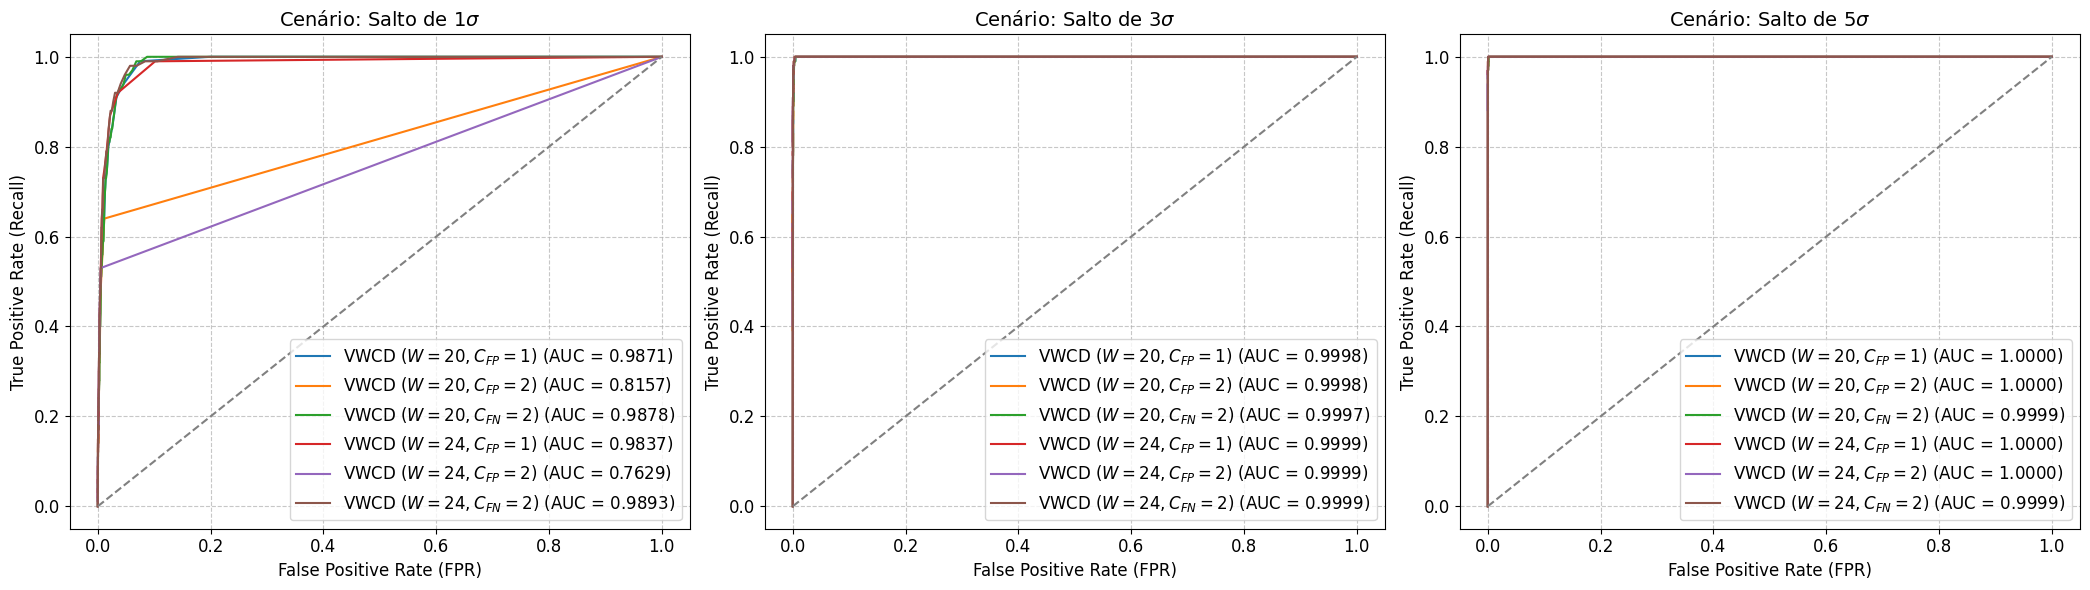

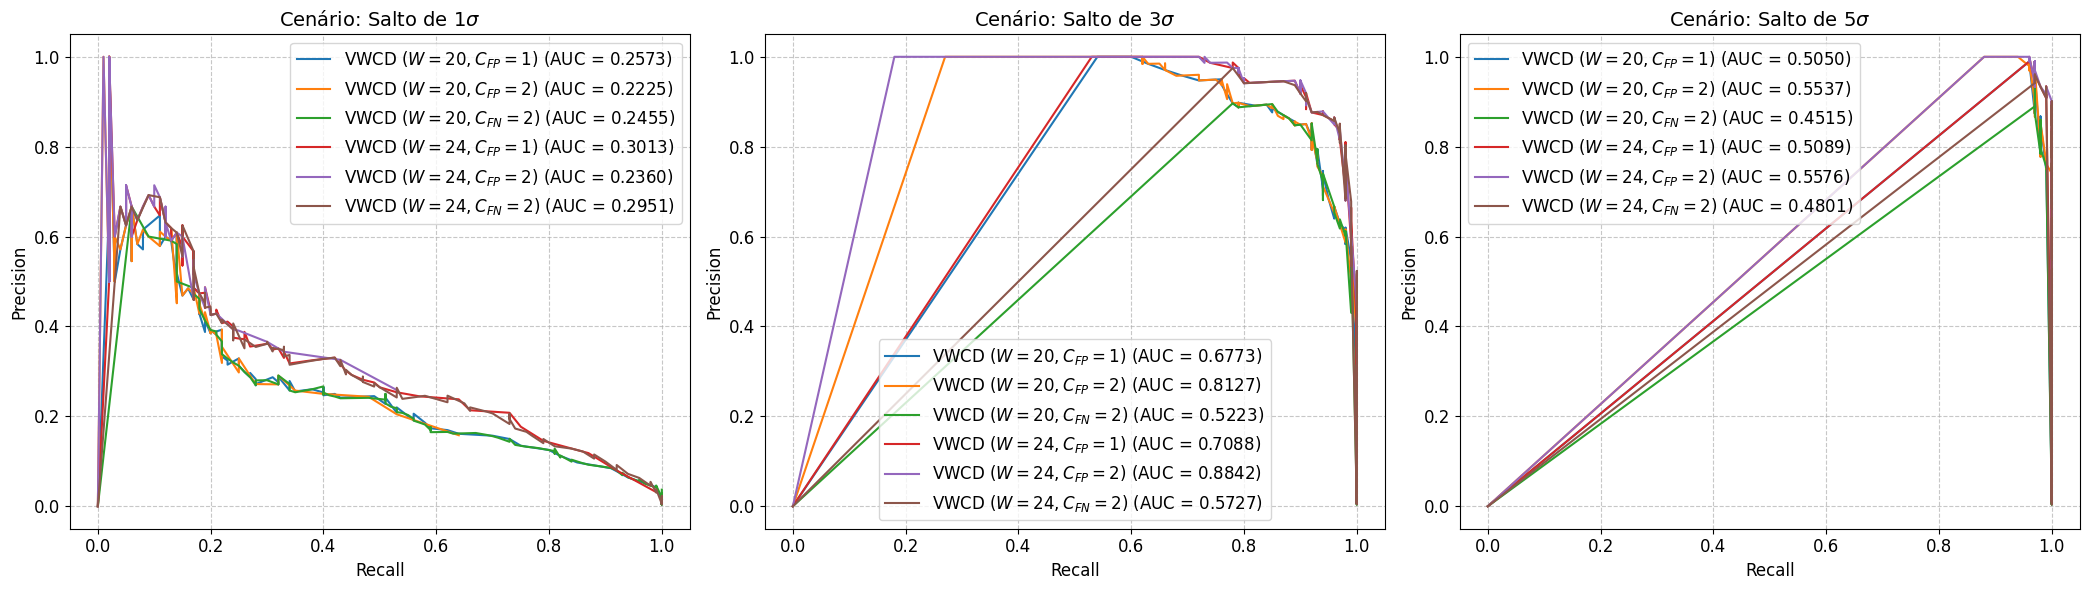

In [64]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# (Nota: Sim, "salto" é uma excelente tradução no contexto de séries temporais. 
# Outra opção muito comum na literatura é "deslocamento".)

def plot_grouped_curves(cenarios: list, methods: list, curve_type: str = 'ROC', cenario_labels: dict = None, method_labels: dict = None):
    if curve_type not in ['ROC', 'PR']:
        raise ValueError("O parâmetro 'curve_type' deve ser 'ROC' ou 'PR'.")
        
    if cenario_labels is None:
        cenario_labels = {c: c for c in cenarios}
    if method_labels is None:
        method_labels = {m: m for m in methods}
        
    n_cenarios = len(cenarios)
    # Aumentando ligeiramente a largura para acomodar fontes maiores
    fig, axes = plt.subplots(1, n_cenarios, figsize=(7 * n_cenarios, 6))
    
    if n_cenarios == 1:
        axes = [axes]
        
    for ax, cenario in zip(axes, cenarios):
        for method in methods:
            file_path = os.path.join("metrics", cenario, f"thresholds_{method}.csv")
            if not os.path.exists(file_path):
                print(f"Warning: File not found {file_path}")
                continue
                
            df = pd.read_csv(file_path)
            m_label = method_labels.get(method, method)
            
            if curve_type == 'ROC':
                df['FPR'] = np.where(
                    (df['FP'] + df['TN']) > 0,
                    df['FP'] / (df['FP'] + df['TN']),
                    0.0
                )
                df = df.sort_values(by='FPR')

                df = pd.concat([
                    pd.DataFrame({'FPR': [0.0], 'Recall': [0.0]}),
                    df[['FPR', 'Recall']],
                    pd.DataFrame({'FPR': [1.0], 'Recall': [1.0]})
                ], ignore_index=True).drop_duplicates()
                
                auc_value = np.trapezoid(df['Recall'], df['FPR'])
                ax.plot(df['FPR'], df['Recall'], linestyle='-', label=f"{m_label} (AUC = {auc_value:.4f})")
                
            elif curve_type == 'PR':
                df = df.sort_values(by='Recall')
                auc_value = np.trapezoid(df['Precision'], df['Recall'])
                ax.plot(df['Recall'], df['Precision'], linestyle='-', label=f"{m_label} (AUC = {auc_value:.4f})")
                
        c_label = cenario_labels.get(cenario, cenario)
        ax.set_title(f"Cenário: {c_label}", fontsize=14)
        
        if curve_type == 'ROC':
            ax.plot([0, 1], [0, 1], color='gray', linestyle='--')
            ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
            ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
            ax.legend(loc='lower right', fontsize=12)
        elif curve_type == 'PR':
            ax.set_xlabel('Recall', fontsize=12)
            ax.set_ylabel('Precision', fontsize=12)
            ax.set_xlim([-0.05, 1.05])
            ax.set_ylim([-0.05, 1.05])
            ax.legend(loc='best', fontsize=12)
            
        ax.tick_params(axis='both', which='major', labelsize=12)
        ax.grid(True, linestyle='--', alpha=0.7)
        
    plt.tight_layout()
    plt.show()


methods = [
    "vwcd_w20_fp1", 
    "vwcd_w20_fp2", 
    "vwcd_w20_fn2", 
    "vwcd_w24_fp1", 
    "vwcd_w24_fp2", 
    "vwcd_w24_fn2"
]
    
cenarios = [
    "teste_m110", 
    "teste_m130", 
    "teste_m150"
]

cenario_labels = {
    "teste_m110": r"Salto de $1\sigma$",
    "teste_m130": r"Salto de $3\sigma$",
    "teste_m150": r"Salto de $5\sigma$"
}

method_labels = {
    "vwcd_w20_fp1": r"VWCD ($W=20, C_{FP}=1$)",
    "vwcd_w20_fp2": r"VWCD ($W=20, C_{FP}=2$)",
    "vwcd_w20_fn2": r"VWCD ($W=20, C_{FN}=2$)",
    "vwcd_w24_fp1": r"VWCD ($W=24, C_{FP}=1$)",
    "vwcd_w24_fp2": r"VWCD ($W=24, C_{FP}=2$)",
    "vwcd_w24_fn2": r"VWCD ($W=24, C_{FN}=2$)"
}

plot_grouped_curves(
    cenarios=cenarios,
    methods=methods,
    curve_type='ROC',
    cenario_labels=cenario_labels,
    method_labels=method_labels
)

plot_grouped_curves(
    cenarios=cenarios,
    methods=methods,
    curve_type='PR',
    cenario_labels=cenario_labels,
    method_labels=method_labels
)

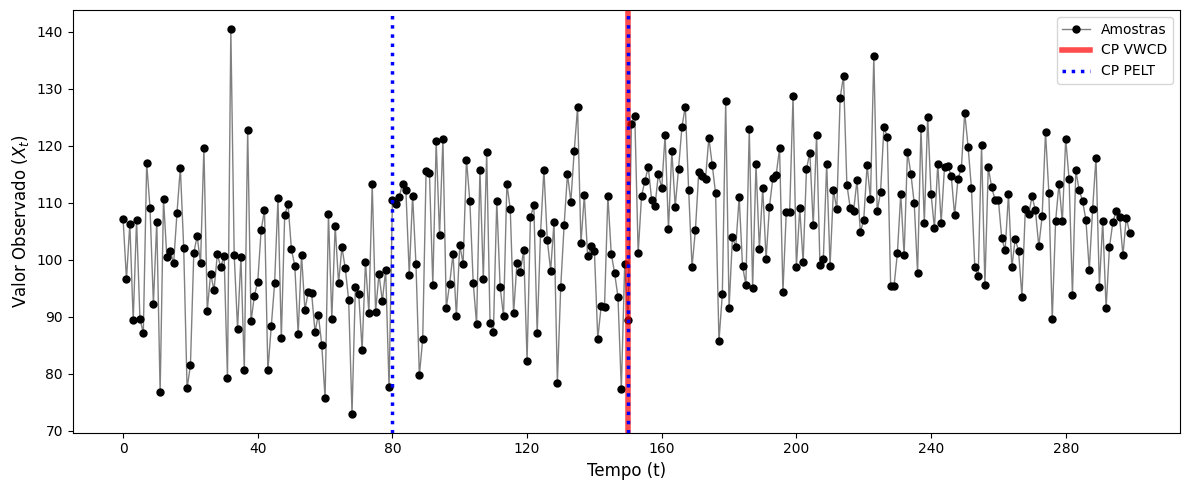

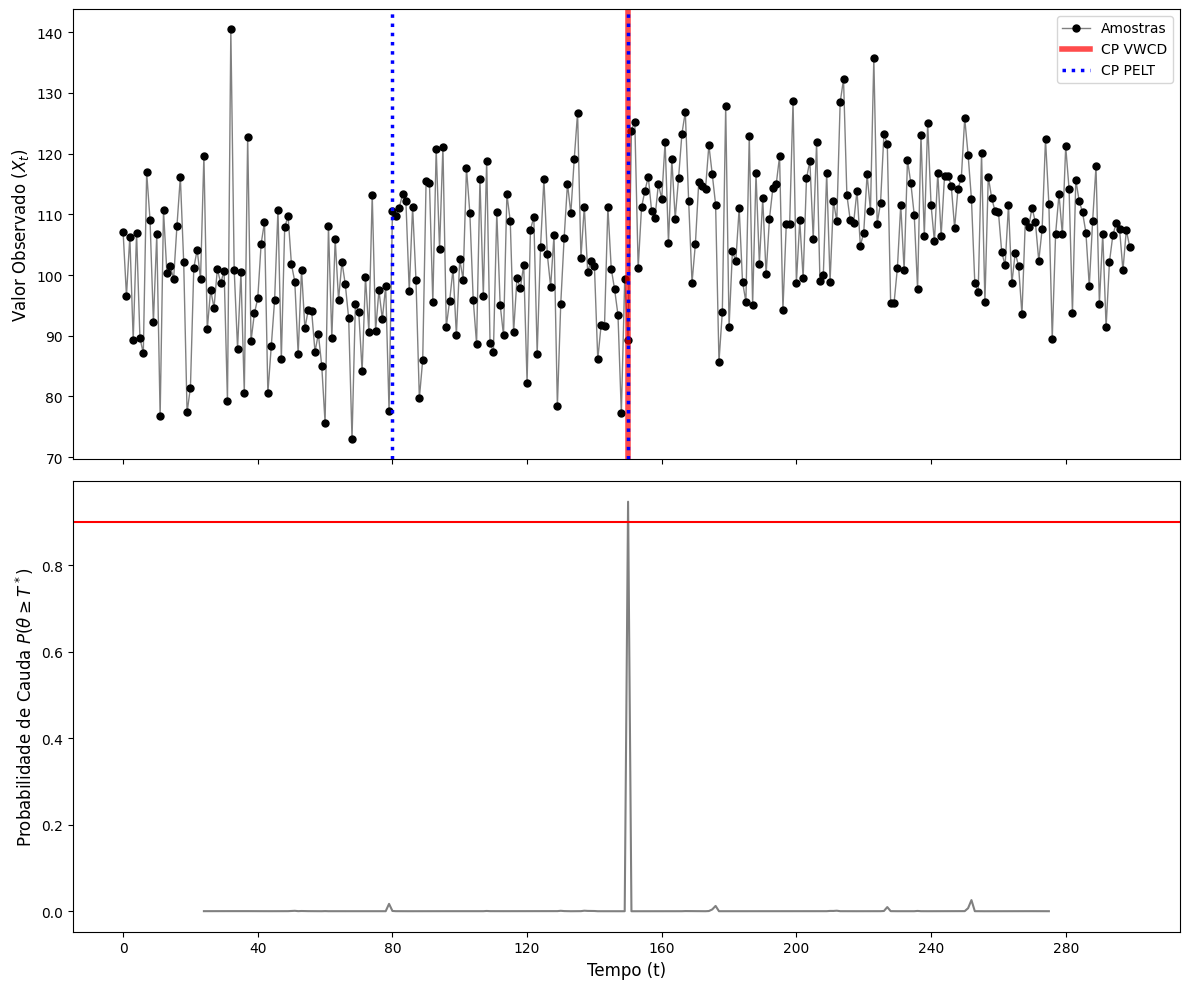

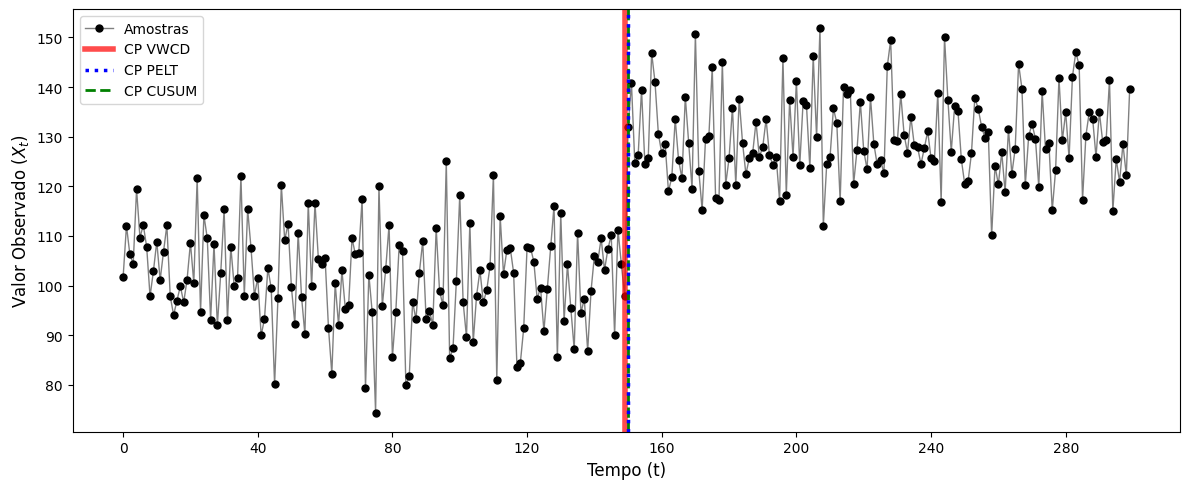

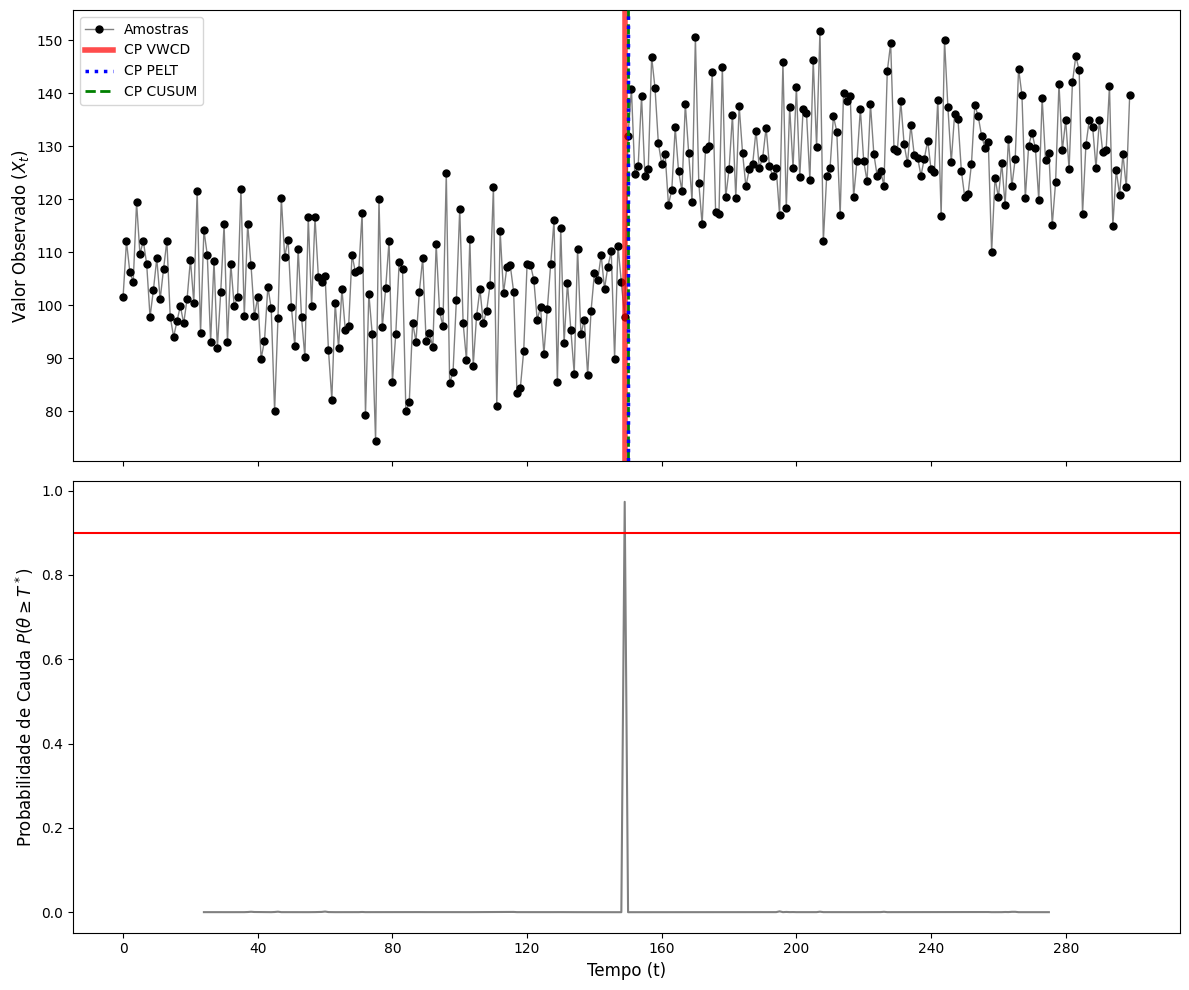

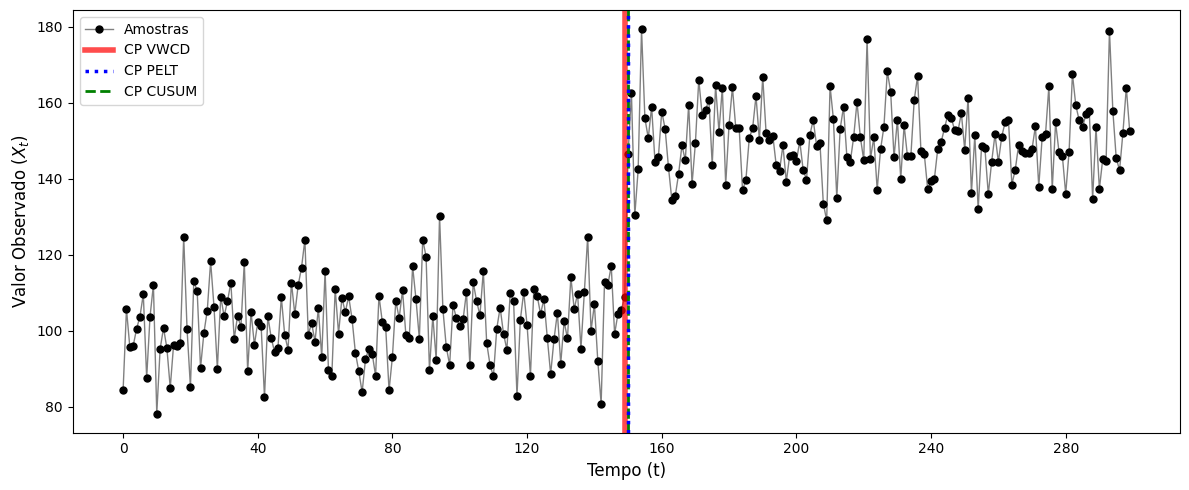

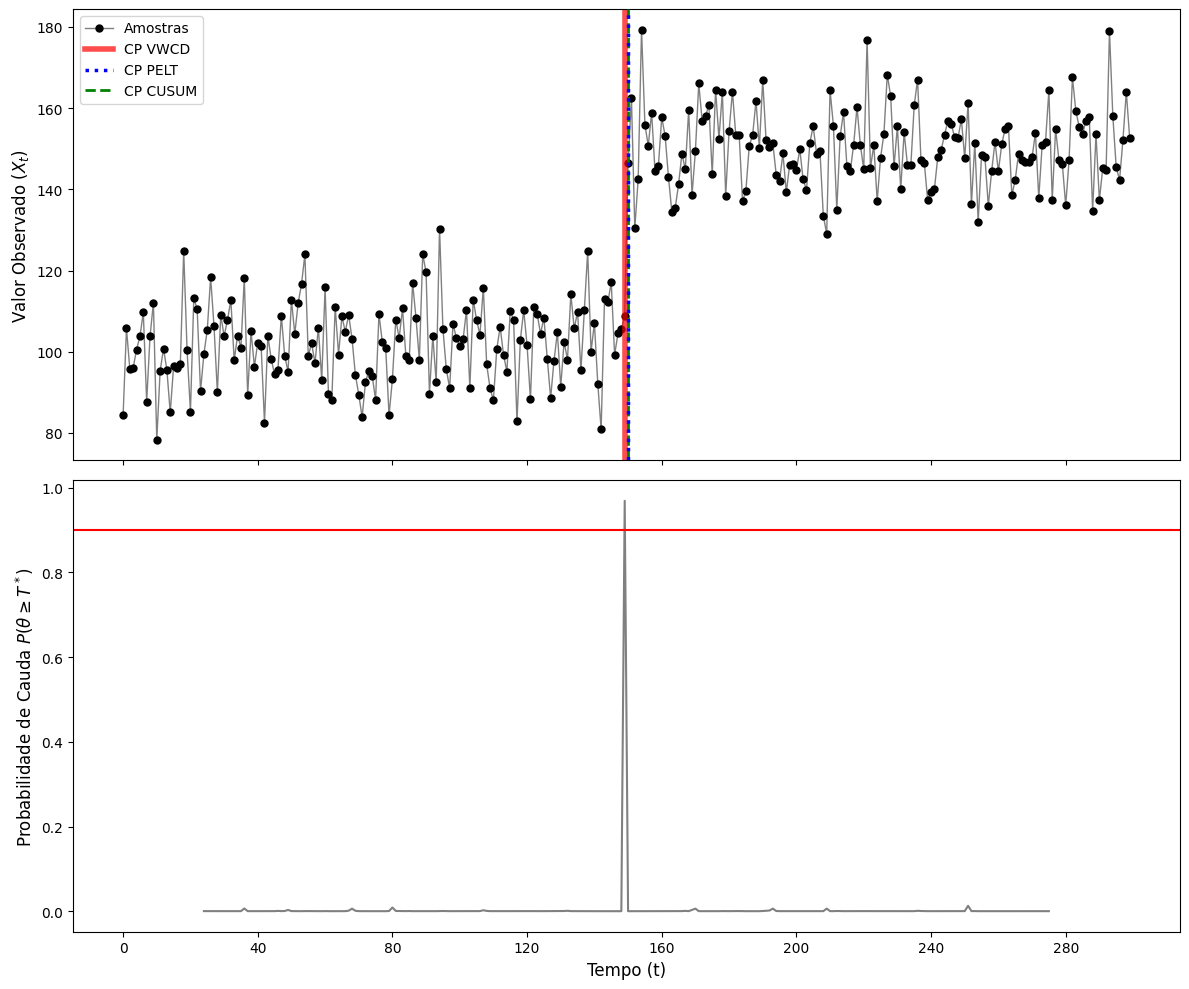

In [73]:
import os
from matplotlib import pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator

def plot_changepoint(cenario, methods, file, threshold=0.95, tail_plot=False, agg_plot=False, slice_window=["", ""], alias="", metric=None, x_axis_type='timestamp'):
    if isinstance(methods, str):
        methods = [methods] if methods else []
        
    base_types = []
    vwcd_method = None
    for m in methods:
        if m.startswith('vwcd'):
            base_types.append('vwcd')
            vwcd_method = m
        elif m.startswith('cusum'):
            base_types.append('cusum')
        elif m.startswith('pelt'):
            base_types.append('pelt')
        else:
            raise ValueError(f"Method '{m}' must start with 'vwcd', 'cusum', or 'pelt'.")
            
    for b_type in set(base_types):
        if base_types.count(b_type) > 1:
            raise ValueError(f"Cannot pass more than one method of type '{b_type}'.")

    if (tail_plot or agg_plot) and not vwcd_method:
        raise ValueError("O gráfico inferior (tail ou agg) só está disponível se um método 'vwcd' for fornecido.")

    start = pd.to_datetime(slice_window[0]) if (len(slice_window) > 0 and slice_window[0]) else None
    end = pd.to_datetime(slice_window[1]) if (len(slice_window) > 1 and slice_window[1]) else None

    def load_and_slice_df(filepath):
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"File not found: {filepath}")
        df = pd.read_csv(filepath)
        df['timestamp'] = pd.to_datetime(df['timestamp'], format='%Y-%m-%d %H:%M:%S')
        if start:
            df = df[df['timestamp'] >= start]
        if end:
            df = df[df['timestamp'] <= end]
        return df.reset_index(drop=True)

    metric_val = metric if metric else cenario
    serie_file = os.path.join('series', metric_val, file)
    df_serie = load_and_slice_df(serie_file)

    if df_serie.empty:
        return
    
    value_column = [col for col in df_serie.columns if col != 'timestamp'][0]

    ts_to_idx = pd.Series(df_serie.index, index=df_serie['timestamp'])

    df_methods = {}
    for m in methods:
        if m.startswith('vwcd'):
            path = os.path.join('results', cenario, m, 'tail_probability_theta_ge_Tstar', file)
        elif m.startswith('cusum'):
            path = os.path.join('results', cenario, m, file)
        elif m.startswith('pelt'):
            path = os.path.join('results', cenario, m, file)
        df_methods[m] = load_and_slice_df(path)

    ax_ts, ax_agg, ax_tail = None, None, None

    if tail_plot and agg_plot:
        fig, (ax_agg, ax_tail) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    elif tail_plot:
        fig, (ax_ts, ax_tail) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    elif agg_plot:
        fig, (ax_ts, ax_agg) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    else:
        fig, ax_ts = plt.subplots(figsize=(12, 5))
    
    x_serie = df_serie['timestamp'] if x_axis_type == 'timestamp' else df_serie.index

    if ax_ts is not None:
        ax_ts.plot(x_serie, df_serie[value_column], label='Amostras', 
                   linewidth=1, color='gray', marker='o', 
                   markerfacecolor='black', markeredgecolor='black', markersize=5)
        ax_ts.set_ylabel(r'Valor Observado ($X_t$)', fontsize=12)
        
        if ax_agg is None and ax_tail is None:
            ax_ts.set_xlabel('Tempo (t)', fontsize=12)
            
        if x_axis_type == 'index':
            ax_ts.xaxis.set_major_locator(MaxNLocator(integer=True))

    active_axes = [ax for ax in [ax_ts, ax_agg, ax_tail] if ax is not None]

    for m in methods:
        df_m = df_methods[m]
        if m.startswith('vwcd'):
            cps_ts = df_m[df_m['P_theta_ge_Tstar'] > threshold]['timestamp']
            color, ls, lw, zo, lbl, alpha = 'red', '-', 4, 2, 'CP VWCD', 0.7
        elif m.startswith('cusum'):
            cps_ts = df_m[df_m['CP'] == 1]['timestamp']
            color, ls, lw, zo, lbl, alpha = 'green', '--', 2, 3, 'CP CUSUM', 1.0
        elif m.startswith('pelt'):
            cps_ts = df_m[df_m['CP'] == 1]['timestamp']
            color, ls, lw, zo, lbl, alpha = 'blue', ':', 2.5, 4, 'CP PELT', 1.0

        cps_x = cps_ts if x_axis_type == 'timestamp' else cps_ts.map(ts_to_idx).dropna()

        for i, cp in enumerate(cps_x):
            if ax_ts is not None:
                ax_ts.axvline(x=cp, color=color, linestyle=ls, linewidth=lw, 
                              alpha=alpha, zorder=zo, label=lbl if i == 0 else "")

    if ax_agg is not None and vwcd_method:
        agg_path = os.path.join('results', cenario, vwcd_method, 'aggregated_entropy_kl', file)
        df_agg = load_and_slice_df(agg_path)
        
        x_agg = df_agg['timestamp'] if x_axis_type == 'timestamp' else df_agg['timestamp'].map(ts_to_idx).dropna()
        
        ax_agg.plot(x_agg, df_agg['mu_agg'], color='gray', label='Aggregated Probability')
        if threshold <= 1.0:
            ax_agg.axhline(y=threshold, color='red', linestyle='-', label=f'Threshold ({threshold})')
        ax_agg.set_ylabel(r"Probabilidade Agregada $\mu(t)$", fontsize=12)
        
        if ax_tail is None:
            ax_agg.set_xlabel('Tempo (t)', fontsize=12)
            
        if x_axis_type == 'index':
            ax_agg.xaxis.set_major_locator(MaxNLocator(integer=True))

    if ax_tail is not None and vwcd_method:
        df_tail = df_methods[vwcd_method]
        
        x_tail = df_tail['timestamp'] if x_axis_type == 'timestamp' else df_tail['timestamp'].map(ts_to_idx).dropna()
        
        ax_tail.plot(x_tail, df_tail['P_theta_ge_Tstar'], color='gray', label='Tail Probability')
        if threshold <= 1.0:
            ax_tail.axhline(y=threshold, color='red', linestyle='-', label=f'Threshold ({threshold})')
        ax_tail.set_ylabel(r"Probabilidade de Cauda $P(\theta \geq T^*)$", fontsize=12)
        ax_tail.set_xlabel('Tempo (t)', fontsize=12)
        
        if x_axis_type == 'index':
            ax_tail.xaxis.set_major_locator(MaxNLocator(integer=True))

    if ax_ts is not None:
        ax_ts.legend(loc='best')
    fig.tight_layout()
    plt.show()
    plt.close("all")

method = ["vwcd_w24_fp2","pelt","cusum"]
threshold = 0.9

cenario = "teste_m110"
file = "teste30.csv"
plot_changepoint(cenario, method, file, threshold=threshold, x_axis_type='index', tail_plot=False, agg_plot=False)
plot_changepoint(cenario, method, file, threshold=threshold, x_axis_type='index', tail_plot=True, agg_plot=False)

cenario = "teste_m130"
file = "teste15.csv"
plot_changepoint(cenario, method, file, threshold=threshold, x_axis_type='index', tail_plot=False, agg_plot=False)
plot_changepoint(cenario, method, file, threshold=threshold, x_axis_type='index', tail_plot=True, agg_plot=False)

cenario = "teste_m150"
file = "teste01.csv"
plot_changepoint(cenario, method, file, threshold=threshold, x_axis_type='index', tail_plot=False, agg_plot=False)
plot_changepoint(cenario, method, file, threshold=threshold, x_axis_type='index', tail_plot=True, agg_plot=False)


Theo_RNP-SP_s03


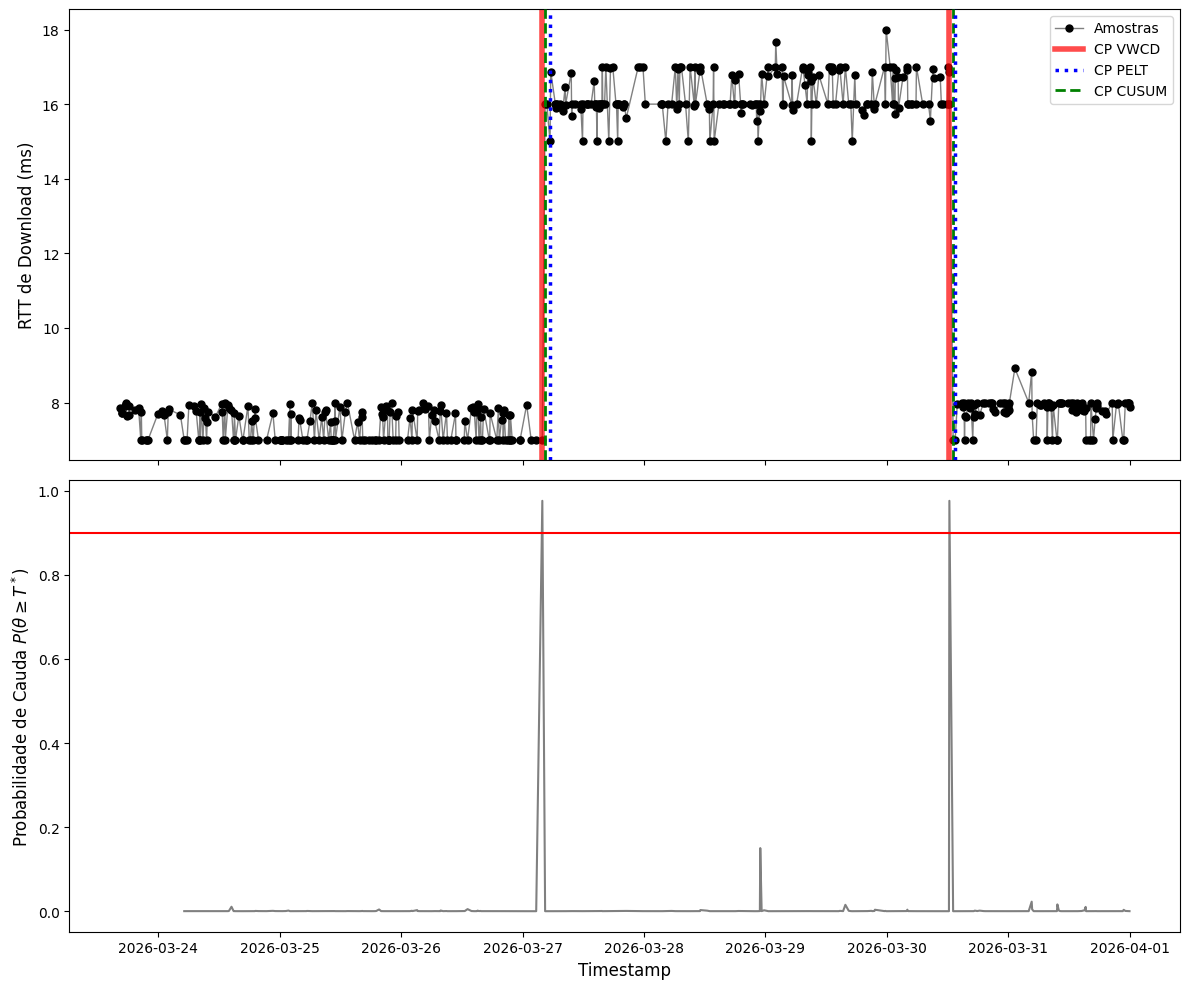

Curi_RNP-SP_s04


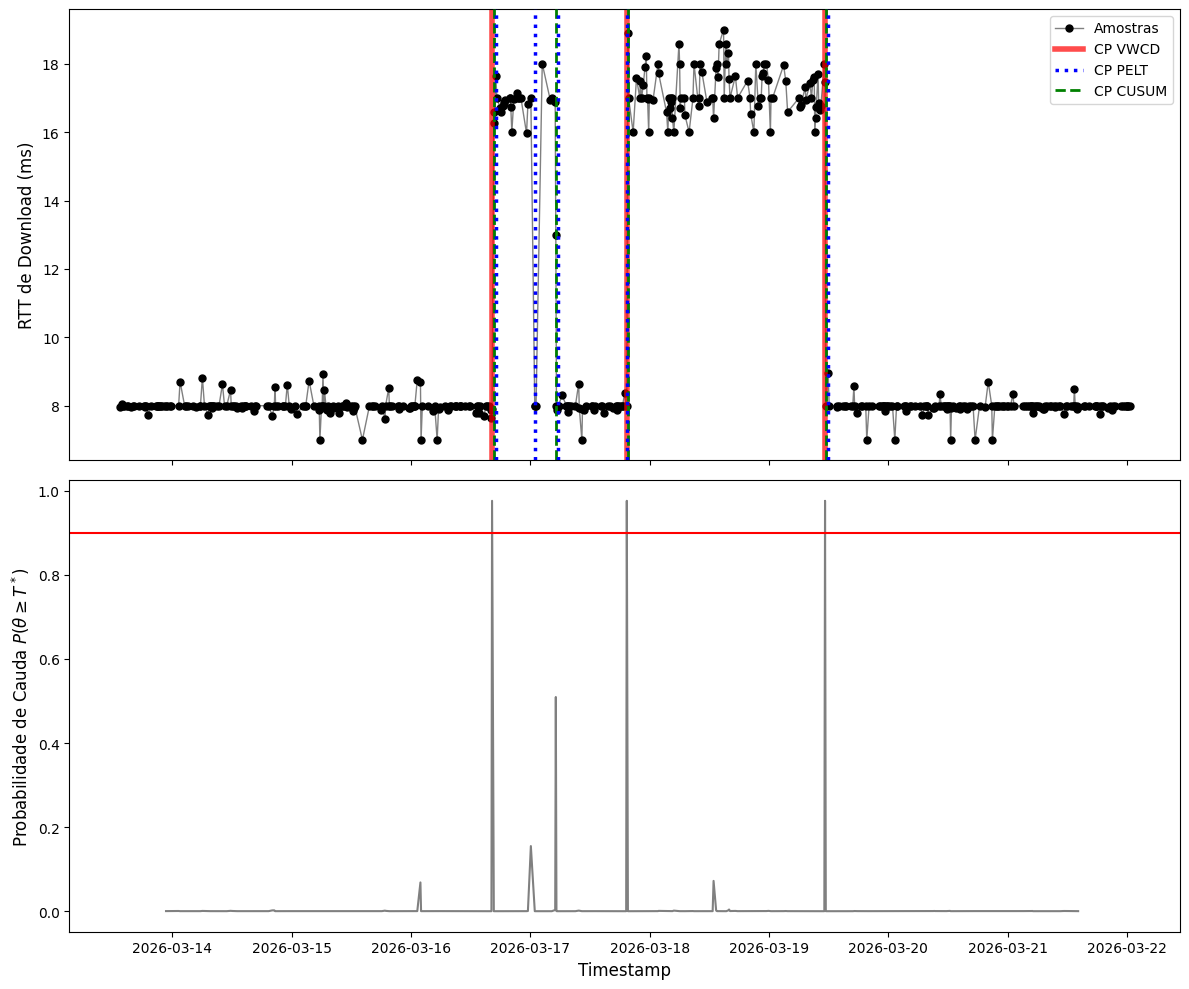

Gigalink-CPS_MLAB1-SP03_s01


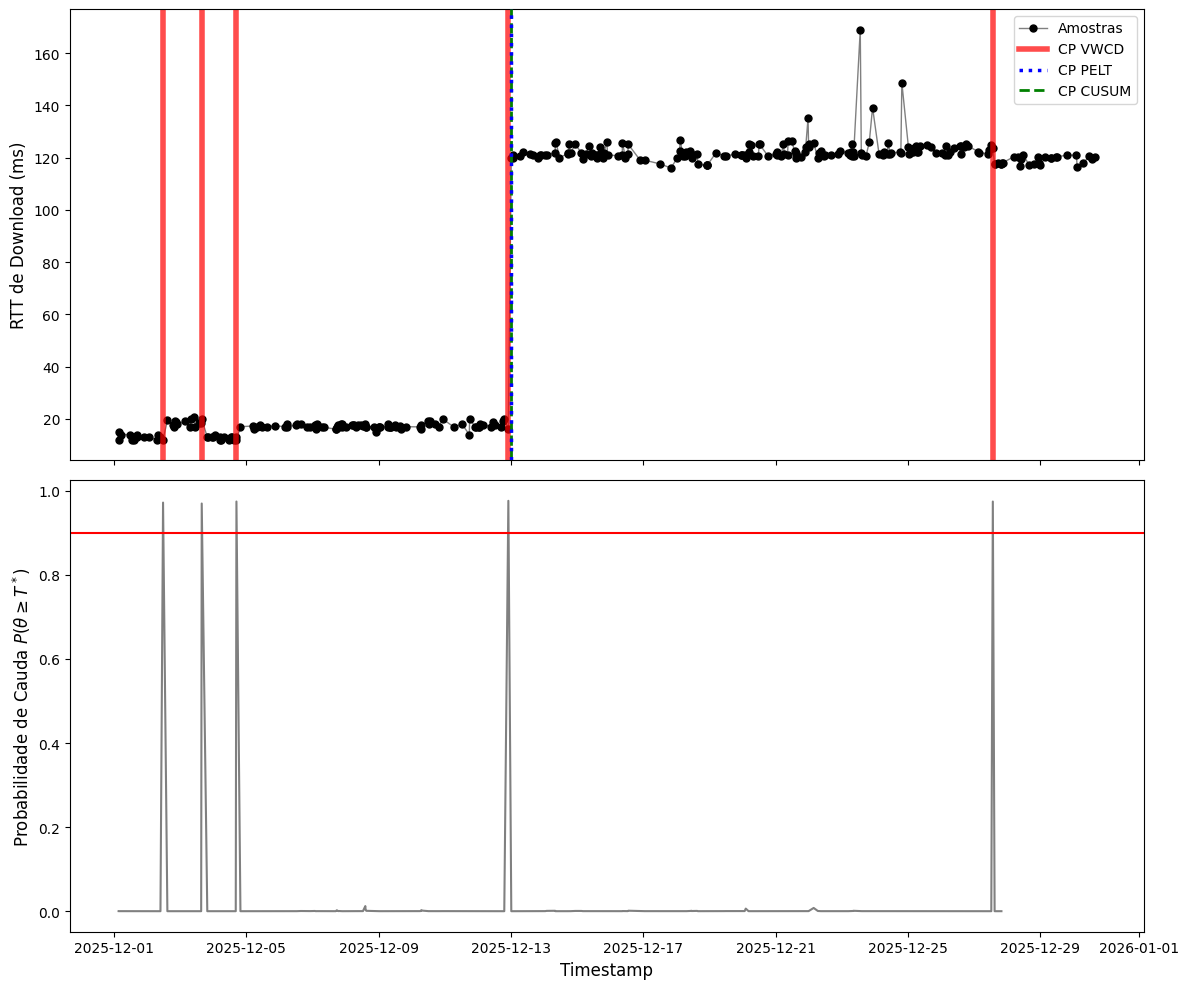

In [84]:
import os
from matplotlib import pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator

def plot_changepoint(cenario, methods, file, threshold=0.95, tail_plot=False, agg_plot=False, slice_window=["", ""], metric=None, x_axis_type='timestamp'):
    if isinstance(methods, str):
        methods = [methods] if methods else []
        
    base_types = []
    vwcd_method = None
    for m in methods:
        if m.startswith('vwcd'):
            base_types.append('vwcd')
            vwcd_method = m
        elif m.startswith('cusum'):
            base_types.append('cusum')
        elif m.startswith('pelt'):
            base_types.append('pelt')
        else:
            raise ValueError(f"Method '{m}' must start with 'vwcd', 'cusum', or 'pelt'.")
            
    for b_type in set(base_types):
        if base_types.count(b_type) > 1:
            raise ValueError(f"Cannot pass more than one method of type '{b_type}'.")

    if (tail_plot or agg_plot) and not vwcd_method:
        raise ValueError("O gráfico inferior (tail ou agg) só está disponível se um método 'vwcd' for fornecido.")

    start = pd.to_datetime(slice_window[0]) if (len(slice_window) > 0 and slice_window[0]) else None
    end = pd.to_datetime(slice_window[1]) if (len(slice_window) > 1 and slice_window[1]) else None

    def load_and_slice_df(filepath):
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"File not found: {filepath}")
        df = pd.read_csv(filepath)
        df['timestamp'] = pd.to_datetime(df['timestamp'], format='%Y-%m-%d %H:%M:%S')
        if start:
            df = df[df['timestamp'] >= start]
        if end:
            df = df[df['timestamp'] <= end]
        return df.reset_index(drop=True)

    metric_val = metric if metric else cenario
    serie_file = os.path.join('series', metric_val, file)
    df_serie = load_and_slice_df(serie_file)

    if df_serie.empty:
        return
    
    value_column = [col for col in df_serie.columns if col != 'timestamp'][0]

    ts_to_idx = pd.Series(df_serie.index, index=df_serie['timestamp'])

    df_methods = {}
    for m in methods:
        if m.startswith('vwcd'):
            path = os.path.join('results', cenario, m, 'tail_probability_theta_ge_Tstar', file)
        elif m.startswith('cusum'):
            path = os.path.join('results', cenario, m, file)
        elif m.startswith('pelt'):
            path = os.path.join('results', cenario, m, file)
        df_methods[m] = load_and_slice_df(path)

    ax_ts, ax_agg, ax_tail = None, None, None

    if tail_plot and agg_plot:
        fig, (ax_agg, ax_tail) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    elif tail_plot:
        fig, (ax_ts, ax_tail) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    elif agg_plot:
        fig, (ax_ts, ax_agg) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    else:
        fig, ax_ts = plt.subplots(figsize=(12, 5))
    
    x_serie = df_serie['timestamp'] if x_axis_type == 'timestamp' else df_serie.index

    if ax_ts is not None:
        ax_ts.plot(x_serie, df_serie[value_column], label='Amostras', 
                   linewidth=1, color='gray', marker='o', 
                   markerfacecolor='black', markeredgecolor='black', markersize=5)
        # ax_ts.set_ylabel(r'Valor Observado ($X_t$)', fontsize=12)
        ax_ts.set_ylabel(r'RTT de Download (ms)', fontsize=12)
        
        if ax_agg is None and ax_tail is None:
            ax_ts.set_xlabel('Tempo (t)', fontsize=12)
            
        if x_axis_type == 'index':
            ax_ts.xaxis.set_major_locator(MaxNLocator(integer=True))

    active_axes = [ax for ax in [ax_ts, ax_agg, ax_tail] if ax is not None]

    for m in methods:
        df_m = df_methods[m]
        if m.startswith('vwcd'):
            cps_ts = df_m[df_m['P_theta_ge_Tstar'] > threshold]['timestamp']
            color, ls, lw, zo, lbl, alpha = 'red', '-', 4, 2, 'CP VWCD', 0.7
        elif m.startswith('cusum'):
            cps_ts = df_m[df_m['CP'] == 1]['timestamp']
            color, ls, lw, zo, lbl, alpha = 'green', '--', 2, 3, 'CP CUSUM', 1.0
        elif m.startswith('pelt'):
            cps_ts = df_m[df_m['CP'] == 1]['timestamp']
            color, ls, lw, zo, lbl, alpha = 'blue', ':', 2.5, 4, 'CP PELT', 1.0

        cps_x = cps_ts if x_axis_type == 'timestamp' else cps_ts.map(ts_to_idx).dropna()

        for i, cp in enumerate(cps_x):
            if ax_ts is not None:
                ax_ts.axvline(x=cp, color=color, linestyle=ls, linewidth=lw, 
                              alpha=alpha, zorder=zo, label=lbl if i == 0 else "")

    if ax_agg is not None and vwcd_method:
        agg_path = os.path.join('results', cenario, vwcd_method, 'aggregated_entropy_kl', file)
        df_agg = load_and_slice_df(agg_path)
        
        x_agg = df_agg['timestamp'] if x_axis_type == 'timestamp' else df_agg['timestamp'].map(ts_to_idx).dropna()
        
        ax_agg.plot(x_agg, df_agg['mu_agg'], color='gray', label='Aggregated Probability')
        if threshold <= 1.0:
            ax_agg.axhline(y=threshold, color='red', linestyle='-', label=f'Threshold ({threshold})')
        ax_agg.set_ylabel(r"Probabilidade Agregada $\mu(t)$", fontsize=12)
        
        if ax_tail is None:
            ax_agg.set_xlabel('Tempo (t)', fontsize=12)
            
        if x_axis_type == 'index':
            ax_agg.xaxis.set_major_locator(MaxNLocator(integer=True))

    if ax_tail is not None and vwcd_method:
        df_tail = df_methods[vwcd_method]
        
        x_tail = df_tail['timestamp'] if x_axis_type == 'timestamp' else df_tail['timestamp'].map(ts_to_idx).dropna()
        
        ax_tail.plot(x_tail, df_tail['P_theta_ge_Tstar'], color='gray', label='Tail Probability')
        if threshold <= 1.0:
            ax_tail.axhline(y=threshold, color='red', linestyle='-', label=f'Threshold ({threshold})')
        ax_tail.set_ylabel(r"Probabilidade de Cauda $P(\theta \geq T^*)$", fontsize=12)
        # ax_tail.set_xlabel('Tempo (t)', fontsize=12)
        ax_tail.set_xlabel('Timestamp', fontsize=12)
        
        if x_axis_type == 'index':
            ax_tail.xaxis.set_major_locator(MaxNLocator(integer=True))

    if ax_ts is not None:
        ax_ts.legend(loc='best')
    fig.tight_layout()
    plt.show()
    plt.close("all")

method = ["vwcd_w24_fp2","pelt","cusum"]
threshold = 0.9
cenario = "NDT/rtt_down"

file = "Theo_RNP-SP_s03.csv"
slice_window = ["2026-03-01 00:00:00", "2026-03-31 23:59:59"]
print(file[:-4])
plot_changepoint(cenario, method, file, threshold=threshold, tail_plot=True, agg_plot=False, slice_window=slice_window)

file = "Curi_RNP-SP_s04.csv"
slice_window = ["2026-03-01 00:00:00", "2026-03-31 23:59:59"]
print(file[:-4])
plot_changepoint(cenario, method, file, threshold=threshold, tail_plot=True, agg_plot=False, slice_window=slice_window)

file = "Gigalink-CPS_MLAB1-SP03_s01.csv"
slice_window = ["2025-12-01 00:00:00", "2025-12-31 23:59:59"]
print(file[:-4])
plot_changepoint(cenario, method, file, threshold=threshold, tail_plot=True, agg_plot=False, slice_window=slice_window)

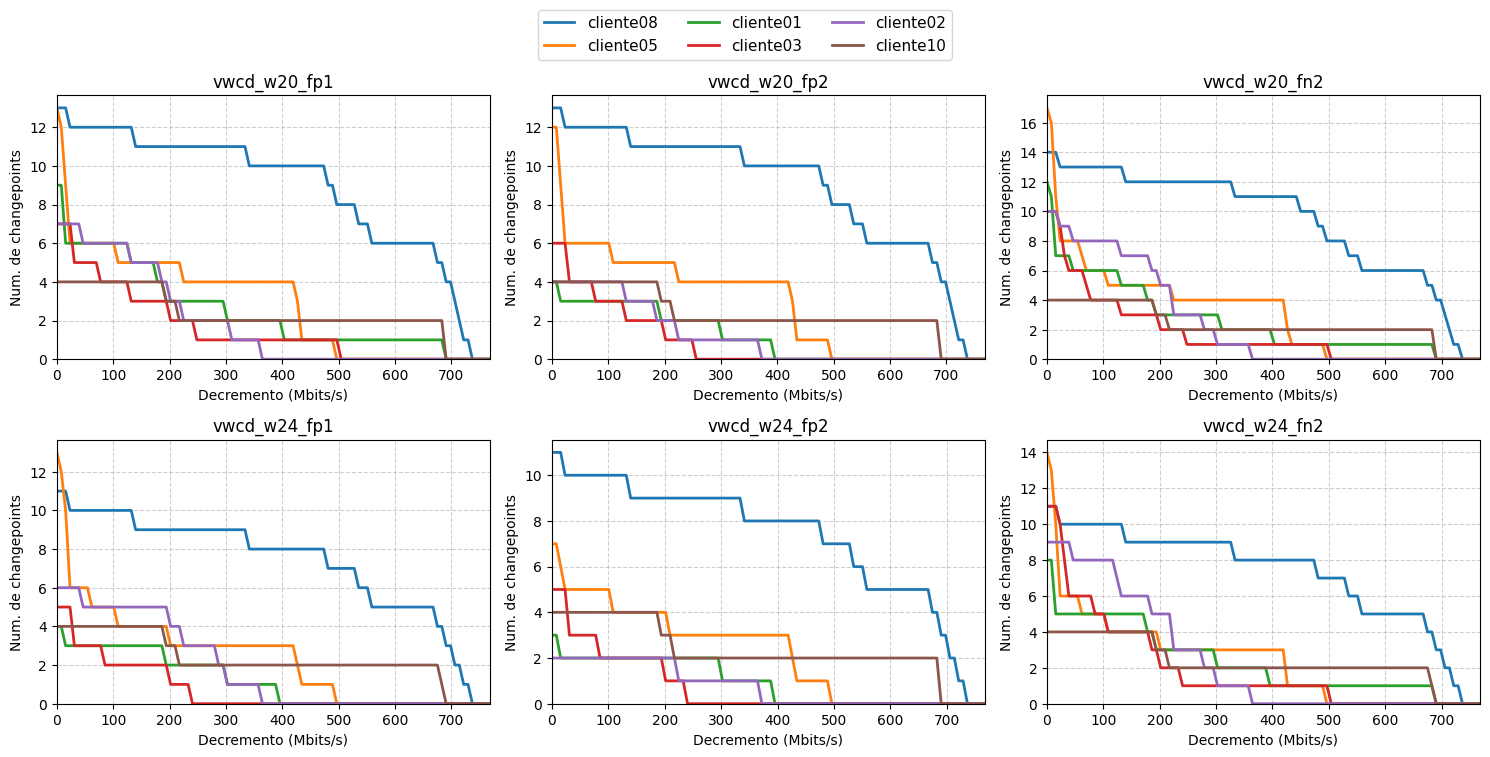

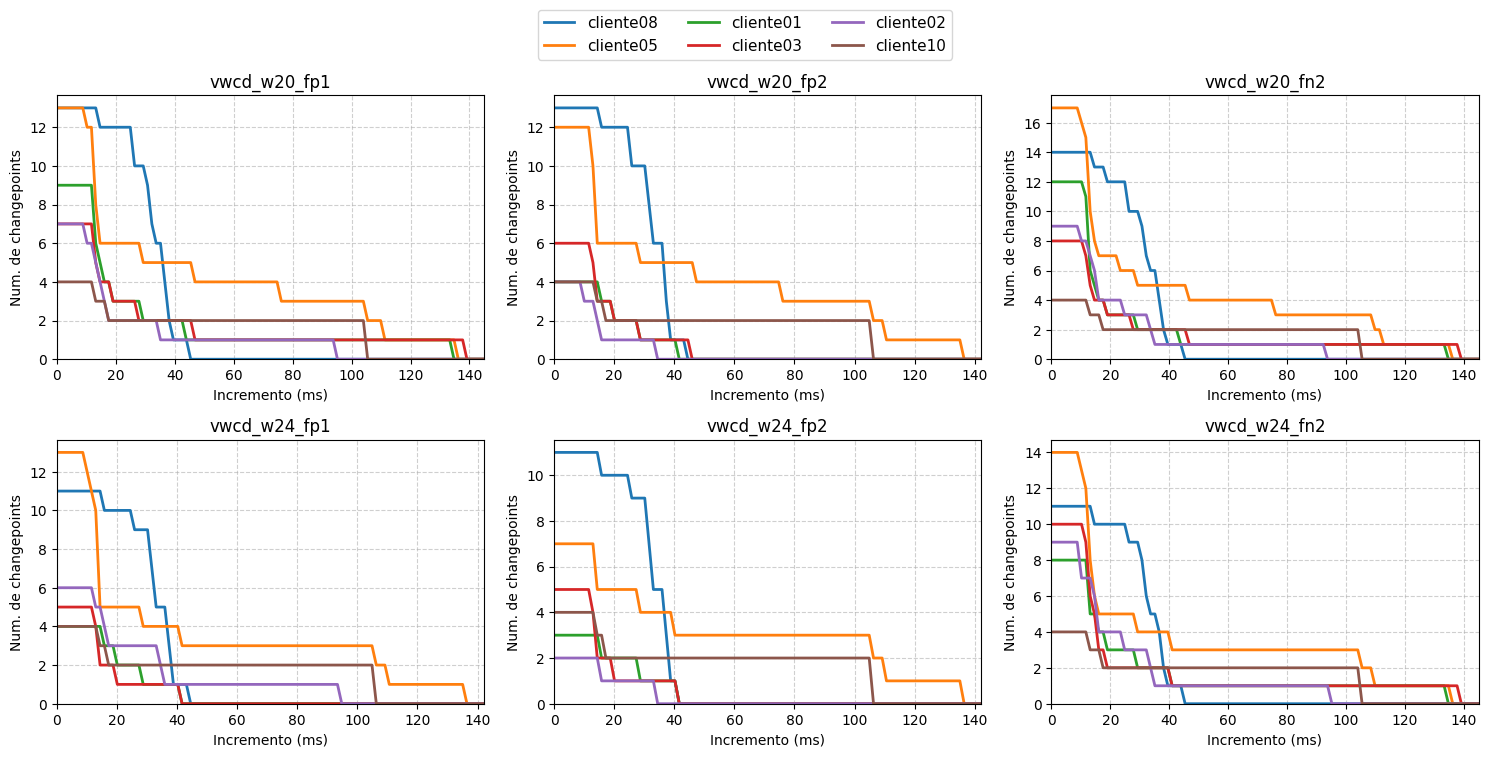

In [90]:
import math
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd
import os
import json

def feature_extraction(scenario, method, threshold, ref_metric):
    folder_path = os.path.join("segments", scenario)
    if method.startswith("vwcd"):
        file_name = f"{method}_{ref_metric}_{threshold}.csv"
    else:
        file_name = f"{method}_{ref_metric}.csv"
    input_path = os.path.join(folder_path, file_name)
    
    if not os.path.exists(input_path):
        print(f"Erro: Arquivo {input_path} not found.")
        return pd.DataFrame()
    
    df = pd.read_csv(input_path)
    
    df = df[df['n_points'] >= 6].copy()
    
    df['series_id'] = df['client'] + "_" + df['server'] + "_" + df['block'].astype(str)
    
    series_counts = df.groupby('series_id').size()
    series_with_changes = series_counts[series_counts > 1].index
    df_filtered = df[df['series_id'].isin(series_with_changes)].copy()
    
    df_filtered = df_filtered.sort_values(['client', 'server', 'block', 'segment_number'])
    
    eps = 1e-9
    features_list = []

    for (client, server, block), group in df_filtered.groupby(['client', 'server', 'block']):
        group = group.reset_index(drop=True)
        
        for i in range(len(group) - 1):
            curr_seg = group.iloc[i]
            next_seg = group.iloc[i+1]
            
            feat = {
                'client': curr_seg['client'],
                'server': curr_seg['server'],
                'block': curr_seg['block'],
                'segment_number': curr_seg['segment_number'],
                'timestamp': curr_seg['final_timestamp']
            }
            
            # RTT Up
            feat['d_rtt_up_abs'] = next_seg['rtt_up_median'] - curr_seg['rtt_up_median']
            feat['d_rtt_up_rel'] = feat['d_rtt_up_abs'] / (curr_seg['rtt_up_median'] + eps)
            
            # RTT Down
            feat['d_rtt_down_abs'] = next_seg['rtt_down_median'] - curr_seg['rtt_down_median']
            feat['d_rtt_down_rel'] = feat['d_rtt_down_abs'] / (curr_seg['rtt_down_median'] + eps)
            
            # Throughput Up
            feat['d_tp_up_abs'] = next_seg['tp_up_median'] - curr_seg['tp_up_median']
            feat['d_tp_up_rel'] = feat['d_tp_up_abs'] / (curr_seg['tp_up_median'] + eps)
            
            # Throughput Down
            feat['d_tp_down_abs'] = next_seg['tp_down_median'] - curr_seg['tp_down_median']
            feat['d_tp_down_rel'] = feat['d_tp_down_abs'] / (curr_seg['tp_down_median'] + eps)
            
            features_list.append(feat)

    if features_list:
        return pd.DataFrame(features_list)
    else:
        print("Nenhuma feature gerada.")
        return pd.DataFrame()

def filtros(df):
    corte = 10 # ms
    # Filtro de corte
    df_filtrado = df[
        ((df['d_rtt_down_abs'] > 0) & (df['d_rtt_down_abs'] >= corte)) |
        ((df['d_rtt_down_abs'] < 0) & (df['d_rtt_down_abs'] <= -corte))|
        ((df['d_rtt_up_abs'] > 0) & (df['d_rtt_up_abs'] >= corte)) |
        ((df['d_rtt_up_abs'] < 0) & (df['d_rtt_up_abs'] <= -corte))     
    ]

    limiares = {
        'd_tp_up_rel': 10,
        'd_rtt_down_rel': 10
    }
    df_filtrado = df_filtrado[~((df_filtrado['d_tp_up_rel'] > limiares['d_tp_up_rel']) | (df_filtrado['d_rtt_down_rel'] > limiares['d_rtt_down_rel']))]
    return df_filtrado


def plot_qos_deg_profile_by_method(df_features_dict, target_clients, metric):
    methods = list(df_features_dict.keys())
    num_methods = len(methods)
    num_cols = 3
    num_rows = math.ceil(num_methods / num_cols)

    fig, axes = plt.subplots(
        num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows), squeeze=False
    )
    axes = axes.flatten()

    if metric == "d_tp_down":
        col = "d_tp_down_abs"
        filter_cond = lambda df: df[df[col] < 0][col].abs()
        label_y = "Num. de changepoints"
        label_x = "Decremento (Mbits/s)"
        # main_title = "Download Throughput Decrement by Method"
    elif metric == "d_rtt_down":
        col = "d_rtt_down_abs"
        filter_cond = lambda df: df[df[col] > 0][col]
        label_x = "Incremento (ms)"
        # main_title = "RTT Downstream Increment by Method"

    handles_labels = {}

    for idx, method_name in enumerate(methods):
        ax = axes[idx]
        df_feat = df_features_dict[method_name]
        
        filtered_data = {}
        all_changes = []

        for target_client in target_clients:
            df_client = df_feat[df_feat["client"] == target_client]
            changes = filter_cond(df_client)

            filtered_data[target_client] = changes
            all_changes.extend(changes.tolist())

        if not all_changes:
            ax.text(
                0.5,
                0.5,
                f"No data for\n{method_name}",
                ha="center",
                va="center",
                fontsize=11,
            )
            ax.set_title(f"{method_name}", fontsize=12)
            continue

        max_x = max(all_changes) * 1.05
        x_thresholds = np.linspace(0, max_x, 100)

        for target_client, changes in filtered_data.items():
            y_counts = [sum(changes >= x) for x in x_thresholds]
            (line,) = ax.plot(
                x_thresholds, y_counts, label=target_client, linewidth=2
            )

            if target_client not in handles_labels:
                handles_labels[target_client] = line

        ax.set_xlabel(label_x, fontsize=10)
        ax.set_ylabel("Num. de changepoints", fontsize=10)
        ax.set_title(f"{method_name}", fontsize=12)
        ax.set_xlim(0, max_x)
        ax.set_ylim(bottom=0)
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        ax.grid(True, linestyle="--", alpha=0.6)

    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    # fig.suptitle(main_title, fontsize=14, fontweight="bold", y=0.98)

    fig.legend(
        handles=list(handles_labels.values()),
        labels=list(handles_labels.keys()),
        loc="upper center",
        bbox_to_anchor=(0.5, 0.95),
        ncol=3,
        fontsize=11,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.88])
    plt.show()

# 1. Parâmetros globais
scenario = "NDT"
lista_methods = ["vwcd_w20_fp1","vwcd_w20_fp2", "vwcd_w20_fn2", "vwcd_w24_fp1","vwcd_w24_fp2", "vwcd_w24_fn2"]
threshold = 0.90
ref_metric = "rtt_down"
target_clients = ['Land', 'Theo', 'Edson', 'Curi', 'Edworld', 'Gigalink-CDI']

# 2. Pipeline: Executa a extração e os filtros para cada método dinamicamente
df_features_dict = {}

for method in lista_methods:
    # Extrai os dados do método atual
    df_raw = feature_extraction(scenario, method, threshold, ref_metric)

    # Aplica os filtros (garantindo que não dê erro se o DF vier vazio)
    if not df_raw.empty:
        df_filtered = filtros(df_raw)
        # Armazena no dicionário usando o nome do método como chave
        df_features_dict[method] = df_filtered



# 3. Gerar o gráfico com o dicionário de dados prontos
with open(os.path.join("NDT dataset", "mapping_log.json"), "r", encoding="utf-8") as f:
    mapping = json.load(f)

inv_client_map = {v: k for k, v in mapping["client_map"].items()}
inv_server_map = {v: k for k, v in mapping["server_map"].items()}

target_clients = [inv_client_map.get(c, c) for c in target_clients]

for method in df_features_dict:
    if not df_features_dict[method].empty:
        df_features_dict[method]["client"] = df_features_dict[method]["client"].map(inv_client_map).fillna(df_features_dict[method]["client"])
        df_features_dict[method]["server"] = df_features_dict[method]["server"].map(inv_server_map).fillna(df_features_dict[method]["server"])

plot_qos_deg_profile_by_method(
    df_features_dict, target_clients, metric="d_tp_down"
)

plot_qos_deg_profile_by_method(
    df_features_dict, target_clients, metric="d_rtt_down"
)

In [127]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Configurações de Aparência ---
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

# --- Parâmetros do Estudo ---
SCENARIO = "NDT"
METHOD = "vwcd_w24_fp2"
REF_METRIC = "rtt_down"
THRESHOLD = 0.90

# --- Caminho do Arquivo de Features ---
base_path = os.path.join("features", SCENARIO)
if METHOD.startswith("vwcd"):
    file_name = f"features_{METHOD}_{REF_METRIC}_{THRESHOLD}.csv"
else:
    file_name = f"features_{METHOD}_{REF_METRIC}.csv"

full_path = os.path.join(base_path, file_name)

# --- Carregamento ---
df = pd.read_csv(full_path)

abs_rel = 'rel'
df['d_rtt_up'] = df[f'd_rtt_up_{abs_rel}'] 
df['d_rtt_down'] = df[f'd_rtt_down_{abs_rel}']
relativa_absoluta = 'Relativa' if abs_rel == 'rel' else 'Absoluta'

corte = 10 # ms
# Filtro de corte
df_filtrado = df[
    ((df['d_rtt_down_abs'] > 0) & (df['d_rtt_down_abs'] >= corte)) |
    ((df['d_rtt_down_abs'] < 0) & (df['d_rtt_down_abs'] <= -corte))|
    ((df['d_rtt_up_abs'] > 0) & (df['d_rtt_up_abs'] >= corte)) |
    ((df['d_rtt_up_abs'] < 0) & (df['d_rtt_up_abs'] <= -corte))     
]

limiares = {
    'd_tp_up': 10,
    'd_rtt_down': 10
}
df_filtrado = df_filtrado[~((df_filtrado['d_tp_up'] > limiares['d_tp_up']) | (df_filtrado['d_rtt_down'] > limiares['d_rtt_down']))]

# --- Análise de Sincronização e Distribuições de Variação (Deltas) ---

# Seleção das métricas e configurações de plotagem
metrics_to_plot = [
    ('d_rtt_down', f'Variação {relativa_absoluta} RTT Down', 'teal'),
    ('d_tp_down', f'Variação {relativa_absoluta} Throughput Down', 'darkred'),
    ('d_pl', 'Variação Relativa Packet Loss', 'indigo'),
    ('d_rtt_up', 'Variação Relativa RTT Up', 'darkcyan'),
    ('d_tp_up', 'Variação Relativa Throughput Up', 'firebrick')
]

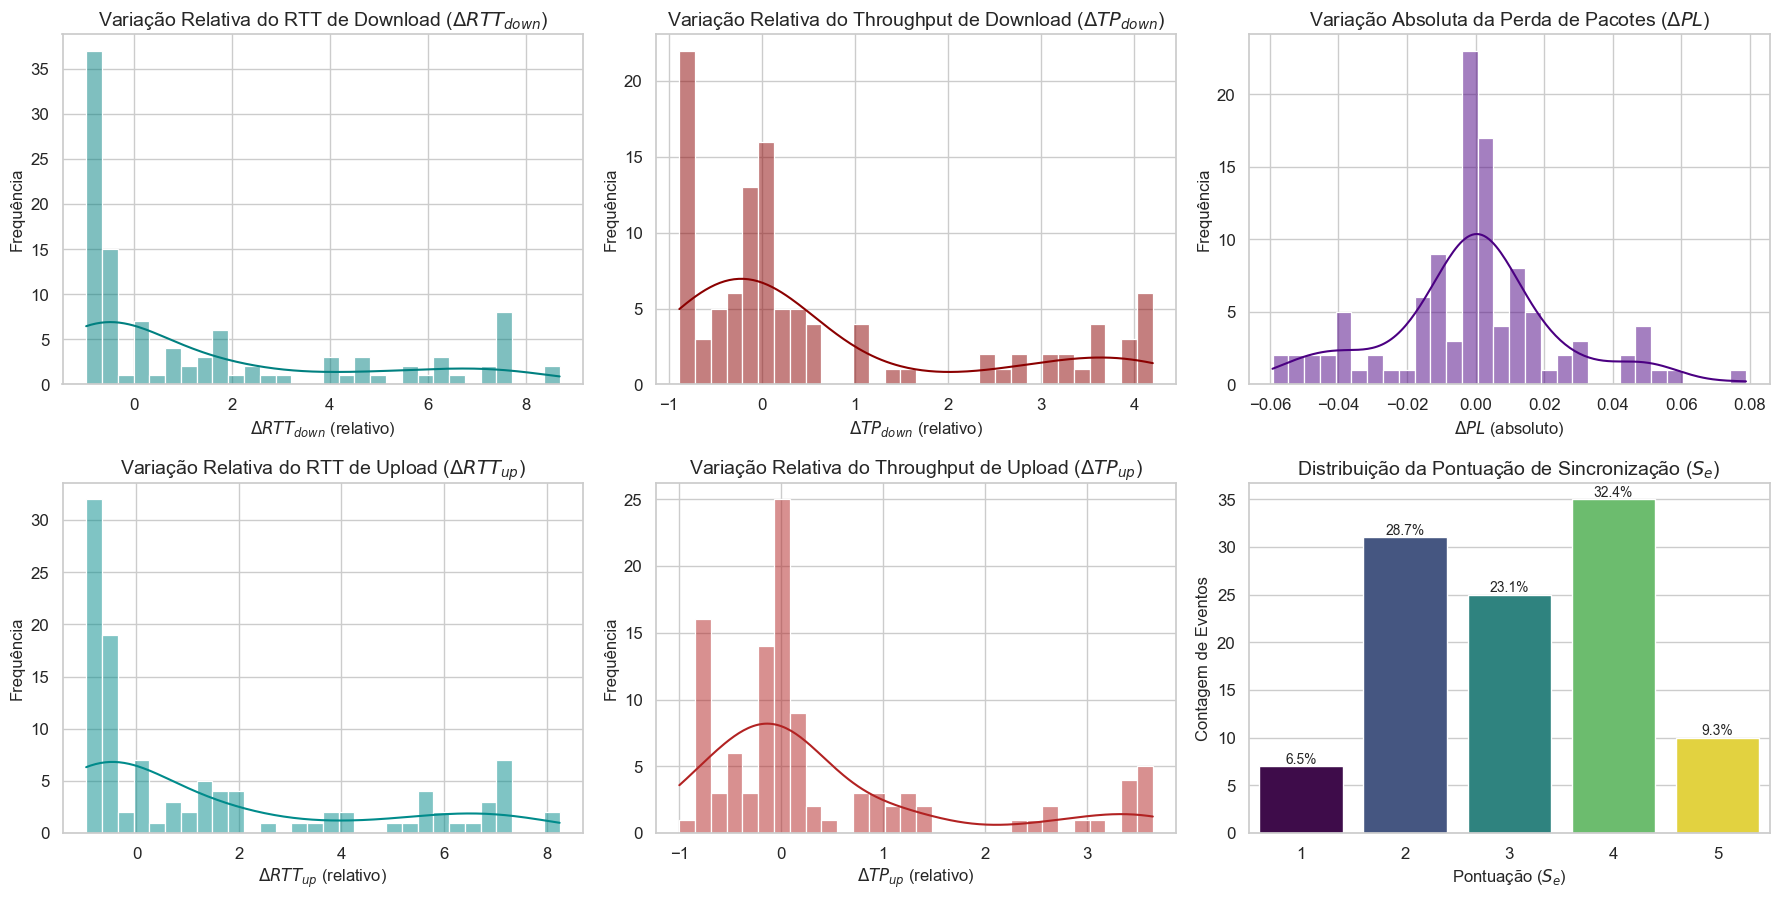

In [129]:
METRICS_INFO = {
    'd_rtt_down': r'Variação Relativa do RTT de Download ($\Delta RTT_{down}$)',
    'd_tp_down': r'Variação Relativa do Throughput de Download ($\Delta TP_{down}$)',
    'd_pl': r'Variação Absoluta da Perda de Pacotes ($\Delta PL$)',
    'd_rtt_up': r'Variação Relativa do RTT de Upload ($\Delta RTT_{up}$)',
    'd_tp_up': r'Variação Relativa do Throughput de Upload ($\Delta TP_{up}$)',
    'sync_score': r'Distribuição da Pontuação de Sincronização ($S_e$)'
}

X_LABELS = {
    'd_rtt_down': r'$\Delta RTT_{down}$ (relativo)',
    'd_tp_down': r'$\Delta TP_{down}$ (relativo)',
    'd_pl': r'$\Delta PL$ (absoluto)',
    'd_rtt_up': r'$\Delta RTT_{up}$ (relativo)',
    'd_tp_up': r'$\Delta TP_{up}$ (relativo)'
}

# Criação da figura 2x3 para consolidar todas as análises
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
# plt.suptitle("Análise de Densidade e Sincronização das Características (Features)", fontsize=16)
axes_flat = axes.flatten()

# 1. Plotagem dos Histogramas com KDE para os Deltas (Primeiras 5 posições)
for i, (col, _, color) in enumerate(metrics_to_plot):
    if col in df_filtrado.columns:
        sns.histplot(df_filtrado[col], kde=True, color=color, ax=axes_flat[i], bins=30)
        
        axes_flat[i].set_title(METRICS_INFO.get(col, col), fontsize=14)
        axes_flat[i].set_xlabel(X_LABELS.get(col, r"Valor do $\Delta$"), fontsize=12)
        axes_flat[i].set_ylabel("Frequência", fontsize=12)

# 2. Plotagem do Synchronization Score (S_e) na sexta posição
ax_sync = axes_flat[5]
sns.countplot(
    data=df_filtrado.assign(sync_score=(df_filtrado['sync_score'] * 5).astype(int)), 
    x='sync_score', hue='sync_score', palette='viridis', ax=ax_sync, legend=False
)

ax_sync.set_title(METRICS_INFO['sync_score'], fontsize=14)
ax_sync.set_xlabel(r'Pontuação ($S_e$)', fontsize=12)
ax_sync.set_ylabel("Contagem de Eventos", fontsize=12)

# Adição de labels de porcentagem sobre as barras do Sync Score
total = len(df_filtrado)
for p in ax_sync.patches:
    height = p.get_height()
    if height > 0:
        percentage = f'{100 * height / total:.1f}%'
        ax_sync.annotate(percentage, (p.get_x() + p.get_width() / 2, height), 
                         ha='center', va='bottom', fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

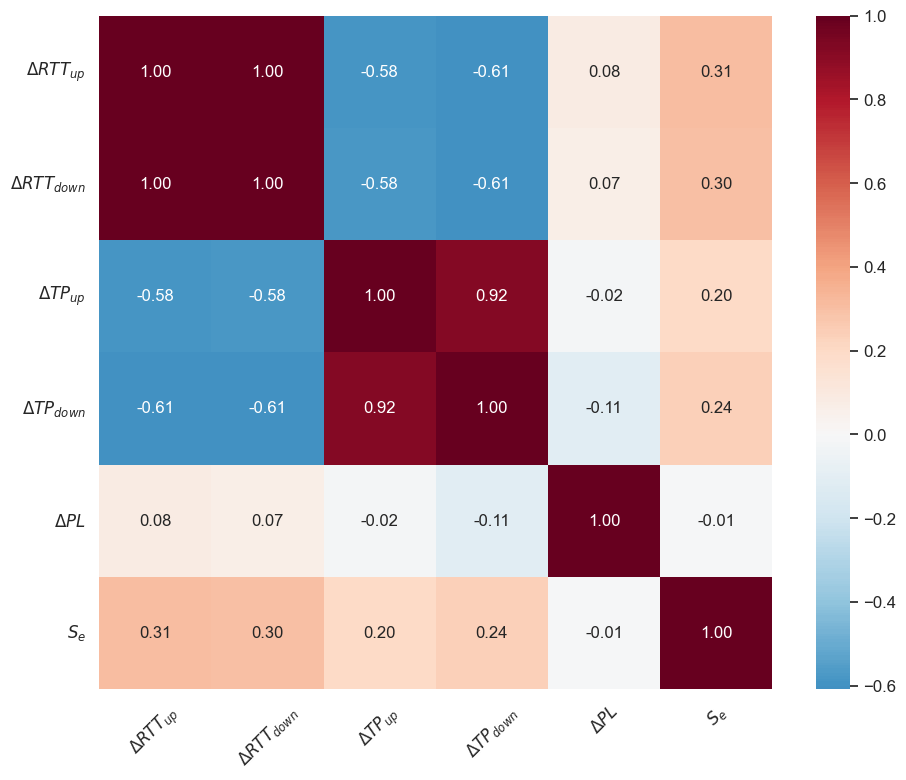

In [131]:
# Dicionário com os labels padronizados para os eixos da matriz
CORR_LABELS = {
    'd_rtt_down': r'$\Delta RTT_{down}$',
    'd_tp_down': r'$\Delta TP_{down}$',
    'd_pl': r'$\Delta PL$',
    'd_rtt_up': r'$\Delta RTT_{up}$',
    'd_tp_up': r'$\Delta TP_{up}$',
    'sync_score': r'$S_e$'
}

# --- Matriz de Correlação Global ---
plt.figure(figsize=(10, 8))
corr_cols = ['d_rtt_up', 'd_rtt_down', 'd_tp_up', 'd_tp_down', 'd_pl', 'sync_score']
correlation_matrix = df_filtrado[corr_cols].corr()

# Aplicando os labels padronizados nos índices e colunas da matriz
correlation_matrix.rename(columns=CORR_LABELS, index=CORR_LABELS, inplace=True)

# Mapa de calor para identificar dependências multivariadas
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='RdBu_r', 
    center=0, 
    fmt=".2f", 
    square=True,
    annot_kws={"size": 12}
)

# plt.title("Matriz de Correlação entre Características", fontsize=16, pad=15)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()

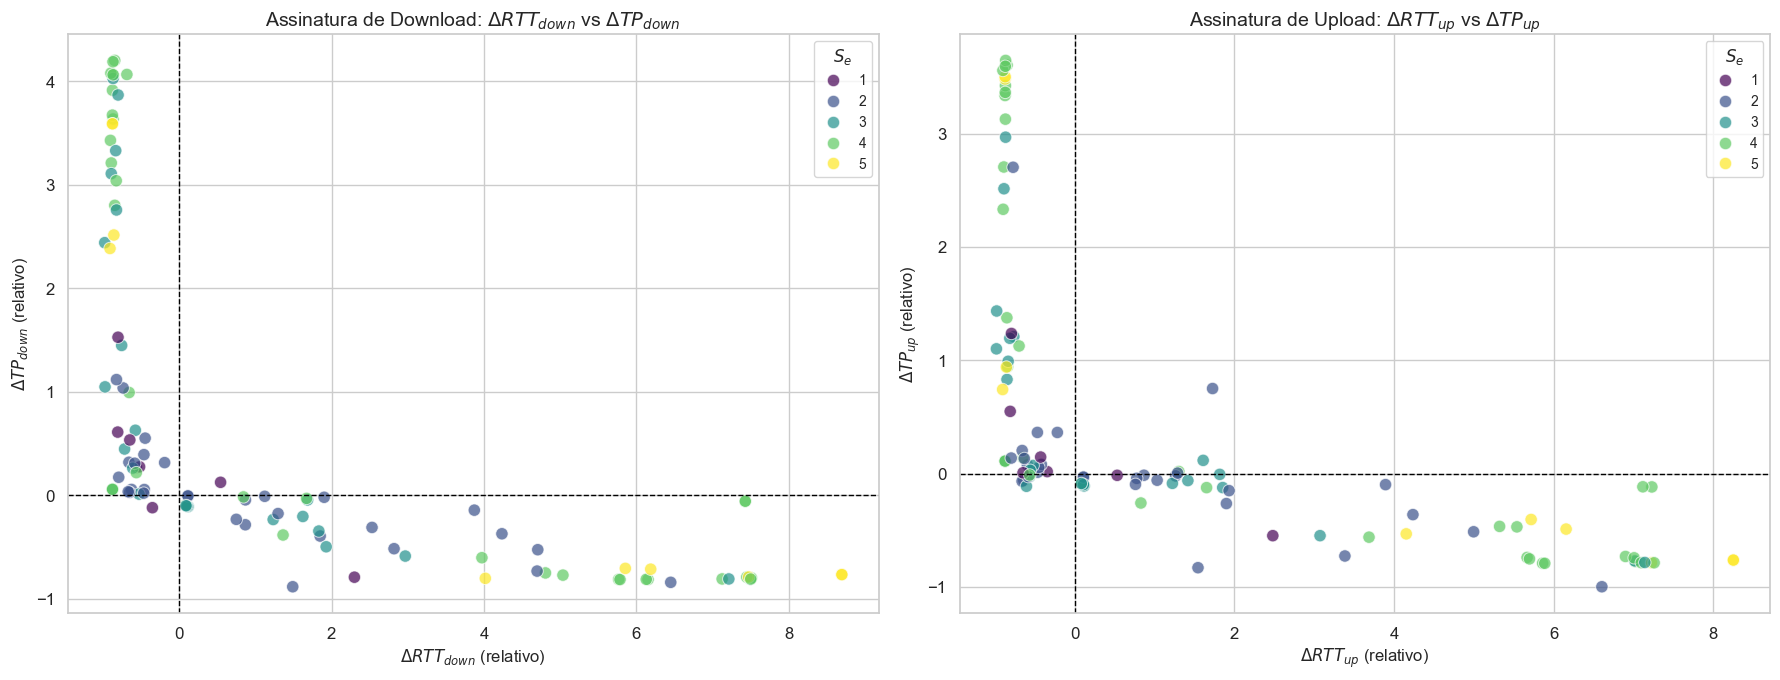

In [133]:
# --- Comparação de Assinaturas: Download vs Upload ---

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Download: RTT vs Throughput
sns.scatterplot(
    data=df_filtrado.assign(sync_score=(df_filtrado['sync_score'] * 5).astype(int)), 
    x='d_rtt_down', y='d_tp_down', 
    hue='sync_score', palette='viridis', s=80, alpha=0.7, ax=axes[0]
)
axes[0].axhline(0, color='black', lw=1, ls='--')
axes[0].axvline(0, color='black', lw=1, ls='--')
axes[0].set_title(r"Assinatura de Download: $\Delta RTT_{down}$ vs $\Delta TP_{down}$", fontsize=14)
axes[0].set_xlabel(r"$\Delta RTT_{down}$ (relativo)", fontsize=12)
axes[0].set_ylabel(r"$\Delta TP_{down}$ (relativo)", fontsize=12)
axes[0].legend(title=r'$S_e$', fontsize=10, title_fontsize=12)

# 2. Upload: RTT vs Throughput
sns.scatterplot(
    data=df_filtrado.assign(sync_score=(df_filtrado['sync_score'] * 5).astype(int)), 
    x='d_rtt_up', y='d_tp_up', 
    hue='sync_score', palette='viridis', s=80, alpha=0.7, ax=axes[1]
)
axes[1].axhline(0, color='black', lw=1, ls='--')
axes[1].axvline(0, color='black', lw=1, ls='--')
axes[1].set_title(r"Assinatura de Upload: $\Delta RTT_{up}$ vs $\Delta TP_{up}$", fontsize=14)
axes[1].set_xlabel(r"$\Delta RTT_{up}$ (relativo)", fontsize=12)
axes[1].set_ylabel(r"$\Delta TP_{up}$ (relativo)", fontsize=12)
axes[1].legend(title=r'$S_e$', fontsize=10, title_fontsize=12)

plt.tight_layout()
plt.show()

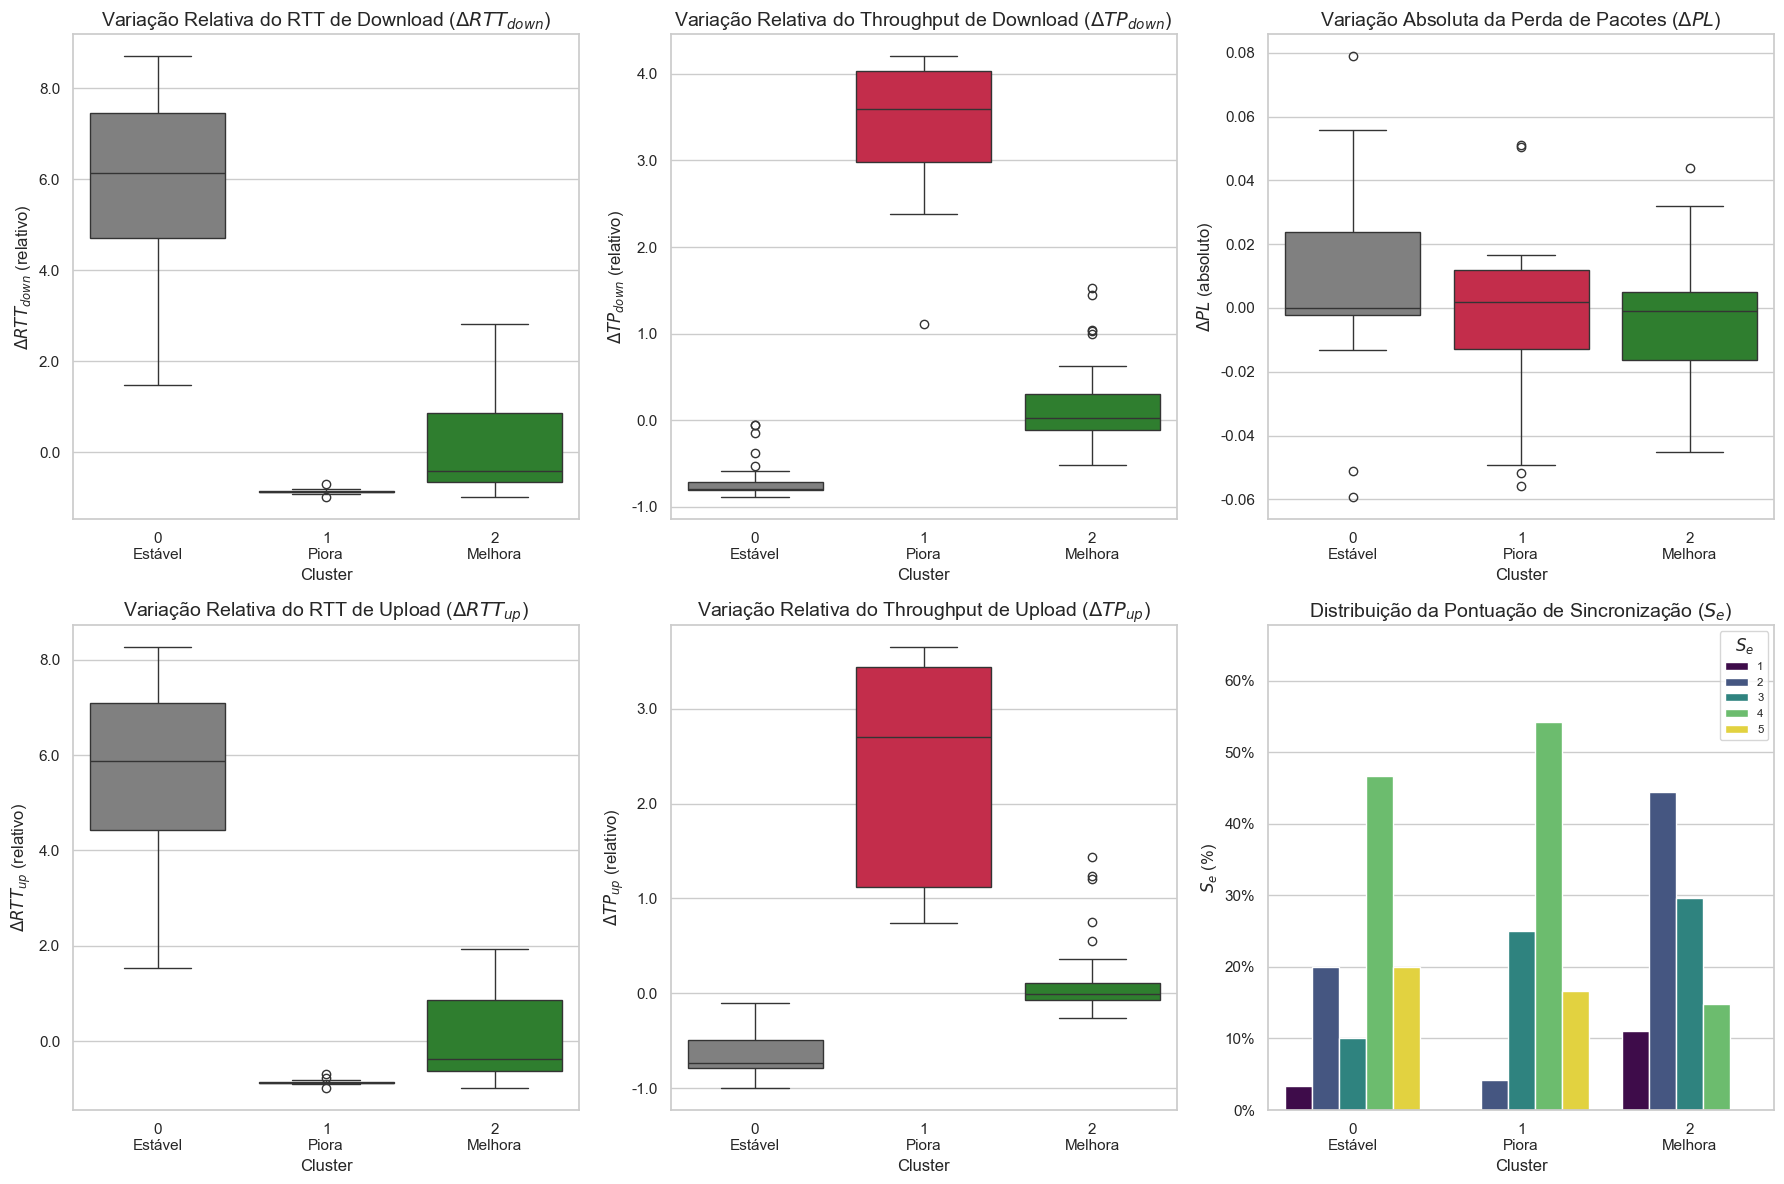

In [122]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter

# ==========================================
# 1. Parâmetros e Configurações
# ==========================================
SCENARIO = "NDT"
METHOD = "vwcd_w24_fp2"
REF_METRIC = "rtt_down"
THRESHOLD = 0.90
K = 3

METRICS_INFO = {
    'd_rtt_down': r'Variação Relativa do RTT de Download ($\Delta RTT_{down}$)',
    'd_tp_down': r'Variação Relativa do Throughput de Download ($\Delta TP_{down}$)',
    'd_pl': r'Variação Absoluta da Perda de Pacotes ($\Delta PL$)',
    'd_rtt_up': r'Variação Relativa do RTT de Upload ($\Delta RTT_{up}$)',
    'd_tp_up': r'Variação Relativa do Throughput de Upload ($\Delta TP_{up}$)',
    'sync_score': r'Distribuição da Pontuação de Sincronização ($S_e$)'
}

Y_LABELS = {
    'd_rtt_down': r'$\Delta RTT_{down}$ (relativo)',
    'd_tp_down': r'$\Delta TP_{down}$ (relativo)',
    'd_pl': r'$\Delta PL$ (absoluto)',
    'd_rtt_up': r'$\Delta RTT_{up}$ (relativo)',
    'd_tp_up': r'$\Delta TP_{up}$ (relativo)',
    'sync_score': r'$S_e$ (%)'
}

CLUSTER_COLORS = {0: 'gray', 1: 'crimson', 2: 'forestgreen'}
CLUSTER_MAP = {0: 'Estável', 1: 'Piora', 2: 'Melhora'}
PLOT_LAYOUT = ['d_rtt_down', 'd_tp_down', 'd_pl', 'd_rtt_up', 'd_tp_up', 'sync_score']

# ==========================================
# 2. Carregamento e Tratamento de Dados
# ==========================================
path = os.path.join("clusters", SCENARIO, METHOD)

if METHOD.startswith("vwcd"):
    filename = f"clusters_K{K:02d}_features_{METHOD}_{REF_METRIC}_{THRESHOLD}.csv"
else:    
    filename = f"clusters_K{K:02d}_features_{METHOD}_{REF_METRIC}.csv"

df_cluster = pd.read_csv(os.path.join(path, filename))

# Tratamento do sync_score
if df_cluster['sync_score'].dtype.kind != 'i':
    df_cluster['sync_score'] = (df_cluster['sync_score'] * 5).astype(int)

# Filtro de outliers
df_plot = df_cluster[(df_cluster['d_rtt_up'] <= 10) & (df_cluster['d_tp_up'] <= 10)]

# ==========================================
# 3. Construção dos Gráficos
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, col in zip(axes.flatten(), PLOT_LAYOUT):
    
    # --- Gráfico Específico por Tipo de Métrica ---
    if col == 'sync_score':
        # Cálculo de proporções para o barplot
        df_props = (df_plot.groupby('cluster')['sync_score']
                    .value_counts(normalize=True)
                    .rename('percent')
                    .reset_index())
        df_props['percent'] *= 100 
        
        sns.barplot(
            x='cluster', y='percent', hue='sync_score', 
            data=df_props, palette='viridis', ax=ax
        )
        
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f%%'))
        ax.set_ylim(0, df_props['percent'].max() * 1.25) 
        ax.legend(title='$S_e$', loc='upper right', fontsize='x-small') 
        ax.set_ylabel(Y_LABELS.get(col, col), fontsize=12)
        
    else:
        # Boxplot para métricas contínuas
        sns.boxplot(
            x='cluster', y=col, data=df_plot, 
            palette=CLUSTER_COLORS, hue='cluster', 
            legend=False, ax=ax
        )
        
        # Formatação de casas decimais
        fmt = '%.2f' if col == 'd_pl' else '%.1f'
        ax.yaxis.set_major_formatter(FormatStrFormatter(fmt))
        ax.set_ylabel(Y_LABELS.get(col, col), fontsize=12)

    # --- Configurações Comuns a Todos os Eixos ---
    ax.set_xticks(ax.get_xticks())
    
    labels = [
        f"{tick.get_text()}\n{CLUSTER_MAP.get(int(tick.get_text()), 'Desconhecido')}" 
        for tick in ax.get_xticklabels()
    ]
    ax.set_xticklabels(labels)
    
    ax.set_title(METRICS_INFO.get(col, col), fontsize=14)
    ax.set_xlabel('Cluster', fontsize=12)

# ==========================================
# 4. Exibição
# ==========================================
plt.tight_layout()
plt.show()